# Seismic Ground Motion Model (GMM) —  EDA

This notebook performs a structured exploratory data analysis (EDA) of the NGA-Sub database before training any Ground Motion Model (GMM). The goal is to understand the data distribution, identify quality issues, examine feature correlations, and uncover patterns critical to model design choices.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
from scipy.stats import kstest, normaltest
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False
})
sns.set_palette('tab10')

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 1. Data Loading & Initial Inspection

**Why:** Understand the shape of the dataset, column types, and immediately spot obvious problems (wrong dtypes, fully-empty columns, mixed-type columns) before any analysis.

In [3]:
# ------------------------------------------------------------------
# UPDATE this path to your actual file
DATA_PATH = 'NGAsub_MegaFlatfile_RotD50_050_R211022_public.xlsx'   # or .xlsx / .txt
# ------------------------------------------------------------------
df = pd.read_excel(DATA_PATH)

print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Shape: 71,340 rows × 227 columns
Memory usage: 210.0 MB


In [4]:
df.head(3)

,NGAsubRSN,DatabaseRegion,NGAsubEQID,NGAsubSSN,Earthquake_Name,YEAR,MODY,HRMN,Earthquake_Magnitude,Hypocenter_Latitude_deg,...,T8pt500S,T9pt000S,T9pt500S,T10pt000S,T11pt000S,T12pt000S,T13pt000S,T14pt000S,T15pt000S,T20pt000S
0,1000001,Alaska,1000001,1000001,Aleutian_Isl-Alaska,2014,623,2053,7.96,51.6928,...,0.000082,0.000095,0.000103,0.000125,0.000138,0.000109,0.000089,0.000064,0.000053,0.000061
1,1000002,Alaska,1000001,1000002,Aleutian_Isl-Alaska,2014,623,2053,7.96,51.6928,...,0.000415,0.000395,0.000405,0.000390,0.000336,0.000332,0.000263,0.000215,0.000187,0.000119
2,1000003,Alaska,1000001,1000003,Aleutian_Isl-Alaska,2014,623,2053,7.96,51.6928,...,0.000092,0.000083,0.000086,0.000082,0.000091,0.000078,0.000071,0.000066,0.000060,0.000055


In [5]:
df.dtypes.value_counts()

float64    178
int64       28
object      21
Name: count, dtype: int64

In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
NGAsubRSN,71340.0,NaN,NaN,NaN,4543043.69344,1491842.203258,1000001.0,4010018.75,4027853.5,6000679.25,7012506.0
DatabaseRegion,71340,7,Japan,40717,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NGAsubEQID,71340.0,NaN,NaN,NaN,4529862.7858,1494069.10752,1000001.0,4000026.0,4000074.0,6000052.25,7000078.0
NGAsubSSN,71340.0,NaN,NaN,NaN,4530020.989108,1489022.822322,1000001.0,4000501.0,4001017.0,6000049.0,7000849.0
Earthquake_Name,71340,1720,Miyagi-oki,2148,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
T12pt000S,71340.0,NaN,NaN,NaN,0.665362,169.068353,-999.0,0.000012,0.00005,0.000175,24658.32
T13pt000S,71340.0,NaN,NaN,NaN,0.408925,145.247177,-999.0,0.000011,0.000043,0.000152,21003.26
T14pt000S,71340.0,NaN,NaN,NaN,0.198772,126.353688,-999.0,0.000009,0.000037,0.000133,18103.61
T15pt000S,71340.0,NaN,NaN,NaN,0.0303,111.433984,-999.0,0.000008,0.000033,0.000117,15767.26


---
## 2. Column Taxonomy

**Why:** With 150+ columns it's essential to categorize them into source (earthquake), path, site, and response (spectral ordinates) groups. This drives all subsequent targeted analyses.

In [7]:
# Identify spectral period columns (T0pt...S / T1pt...S etc.)
sa_cols = [c for c in df.columns if (c.startswith('T0pt') or c.startswith('T') and 'pt' in c and c.endswith('S'))]
# Separate PGA / PGV / PGD
pgm_cols = ['PGA_g', 'PGV_cm_sec', 'PGD_cm']

source_cols = [
    'Earthquake_Magnitude', 'YEAR', 'Hypocenter_Depth_km',
    'Strike_deg', 'Dip_deg', 'Rake_deg', 'Ztor_km', 'Zbor_km',
    'Length_km', 'Width_km', 'Fault_Type', 'Intra_Inter_Flag',
    'Finite_Fault_Model', 'Number_of_Segment'
]
source_cols = [c for c in source_cols if c in df.columns]

path_cols = [
    'EpiD_km', 'HypD_km', 'Rjb_km', 'ClstD_km', 'Rrms_km',
    'Rx_km', 'Ry_km', 'Ry0_km', 'RmaxForAnalysis_km'
]
path_cols = [c for c in path_cols if c in df.columns]

site_cols = [
    'Vs30_Selected_for_Analysis_m_s', 'Sigma_of_Vs30_Selected_for_Analysis_ln_Units',
    'Z1pt0_selected_for_analysis_m', 'Z1pt5_selected_for_analysis_m',
    'Z2pt5_selected_for_analysis_m', 'Vs30_Measured_Inferred_Class',
    'Geomatrix_Site_Code_1st_Letter', 'Sensor_Depth_m'
]
site_cols = [c for c in site_cols if c in df.columns]

print(f'Source params : {len(source_cols)}')
print(f'Path params   : {len(path_cols)}')
print(f'Site params   : {len(site_cols)}')
print(f'SA periods    : {len(sa_cols)}')
print(f'PGM metrics   : {[c for c in pgm_cols if c in df.columns]}')

Source params : 14
Path params   : 9
Site params   : 8
SA periods    : 111
PGM metrics   : ['PGA_g', 'PGV_cm_sec', 'PGD_cm']


---
## 3. Missing Value Analysis

**Why:** Missing data in predictor variables (Vs30, Ztor, distances) or in response variables (SA ordinates) can bias GMM training. Visualizing missingness reveals systematic gaps vs. random gaps, guiding imputation vs. exclusion strategies.

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Missing_Count': missing, 'Missing_%': missing_pct})
miss_df = miss_df[miss_df.Missing_Count > 0].sort_values('Missing_%', ascending=False)

print(f'Columns with missing values: {len(miss_df)} / {df.shape[1]}')
miss_df.head(30)

Columns with missing values: 0 / 227


,Missing_Count,Missing_%


In [9]:
# Focus on key predictors
key_predictors = source_cols + path_cols + site_cols + [c for c in pgm_cols if c in df.columns]
miss_key = miss_df[miss_df.index.isin(key_predictors)]

if not miss_key.empty:
    fig, ax = plt.subplots(figsize=(10, max(4, len(miss_key)*0.35)))
    miss_key['Missing_%'].sort_values().plot.barh(ax=ax, color='steelblue')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing Data — Key Predictors & Response Variables')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values in key predictor / response columns.')

No missing values in key predictor / response columns.


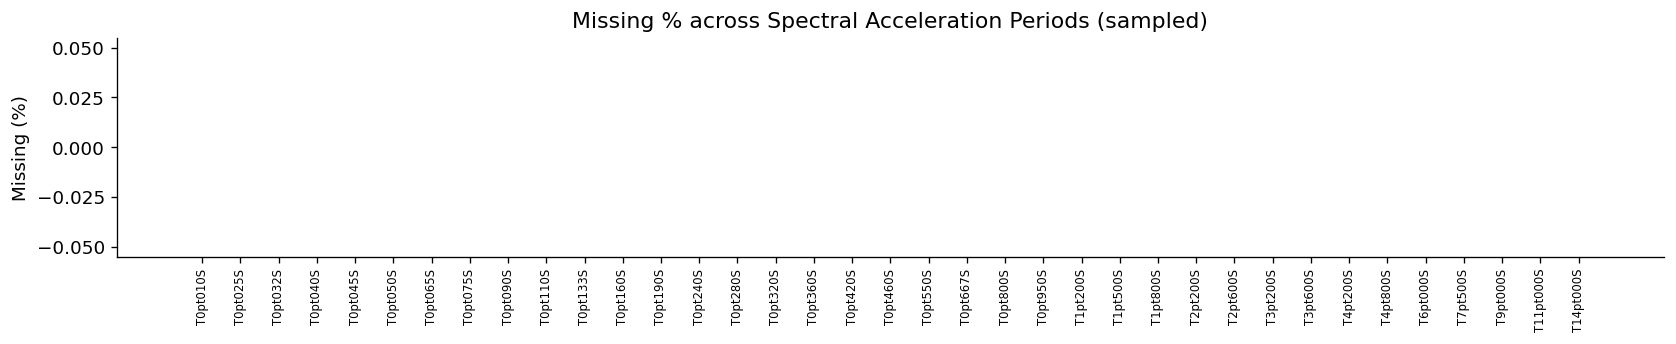

In [10]:
# SA column missingness heatmap (sampled periods)
sa_sample = sa_cols[::max(1, len(sa_cols)//30)]   # ~30 evenly-spaced periods
sa_miss = df[sa_sample].isnull().mean() * 100

fig, ax = plt.subplots(figsize=(14, 3))
ax.bar(range(len(sa_miss)), sa_miss.values, color='coral')
ax.set_xticks(range(len(sa_miss)))
ax.set_xticklabels(sa_miss.index, rotation=90, fontsize=7)
ax.set_ylabel('Missing (%)')
ax.set_title('Missing % across Spectral Acceleration Periods (sampled)')
plt.tight_layout()
plt.show()

---
## 4. Dataset Composition — Event & Record Counts

**Why:** GMMs require records from many independent earthquakes. Checking per-event record counts exposes over-represented events that can dominate training and bias within-event residuals.

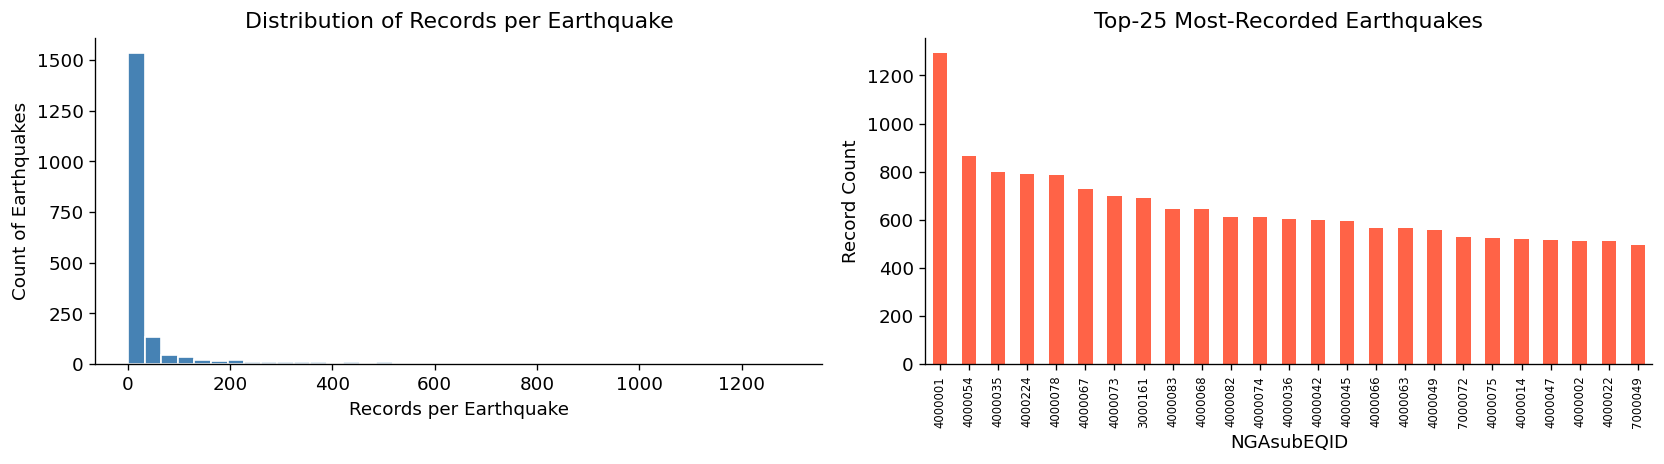

Total unique earthquakes : 1880
Total records            : 71,340
Median records/earthquake: 4


In [11]:
records_per_eq = df.groupby('NGAsubEQID').size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(records_per_eq.values, bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Records per Earthquake')
axes[0].set_ylabel('Count of Earthquakes')
axes[0].set_title('Distribution of Records per Earthquake')

top_n = 25
records_per_eq.head(top_n).plot.bar(ax=axes[1], color='tomato')
axes[1].set_xlabel('NGAsubEQID')
axes[1].set_ylabel('Record Count')
axes[1].set_title(f'Top-{top_n} Most-Recorded Earthquakes')
axes[1].tick_params(axis='x', labelsize=7)

plt.tight_layout()
plt.show()

print(f'Total unique earthquakes : {df["NGAsubEQID"].nunique()}')
print(f'Total records            : {len(df):,}')
print(f'Median records/earthquake: {records_per_eq.median():.0f}')

---
## 5. Source Parameter Distributions

**Why:** Magnitude and depth are the two most critical source predictors in any GMM. Checking their distributions ensures adequate coverage across the magnitude-distance space and flags truncation or clustering artifacts.

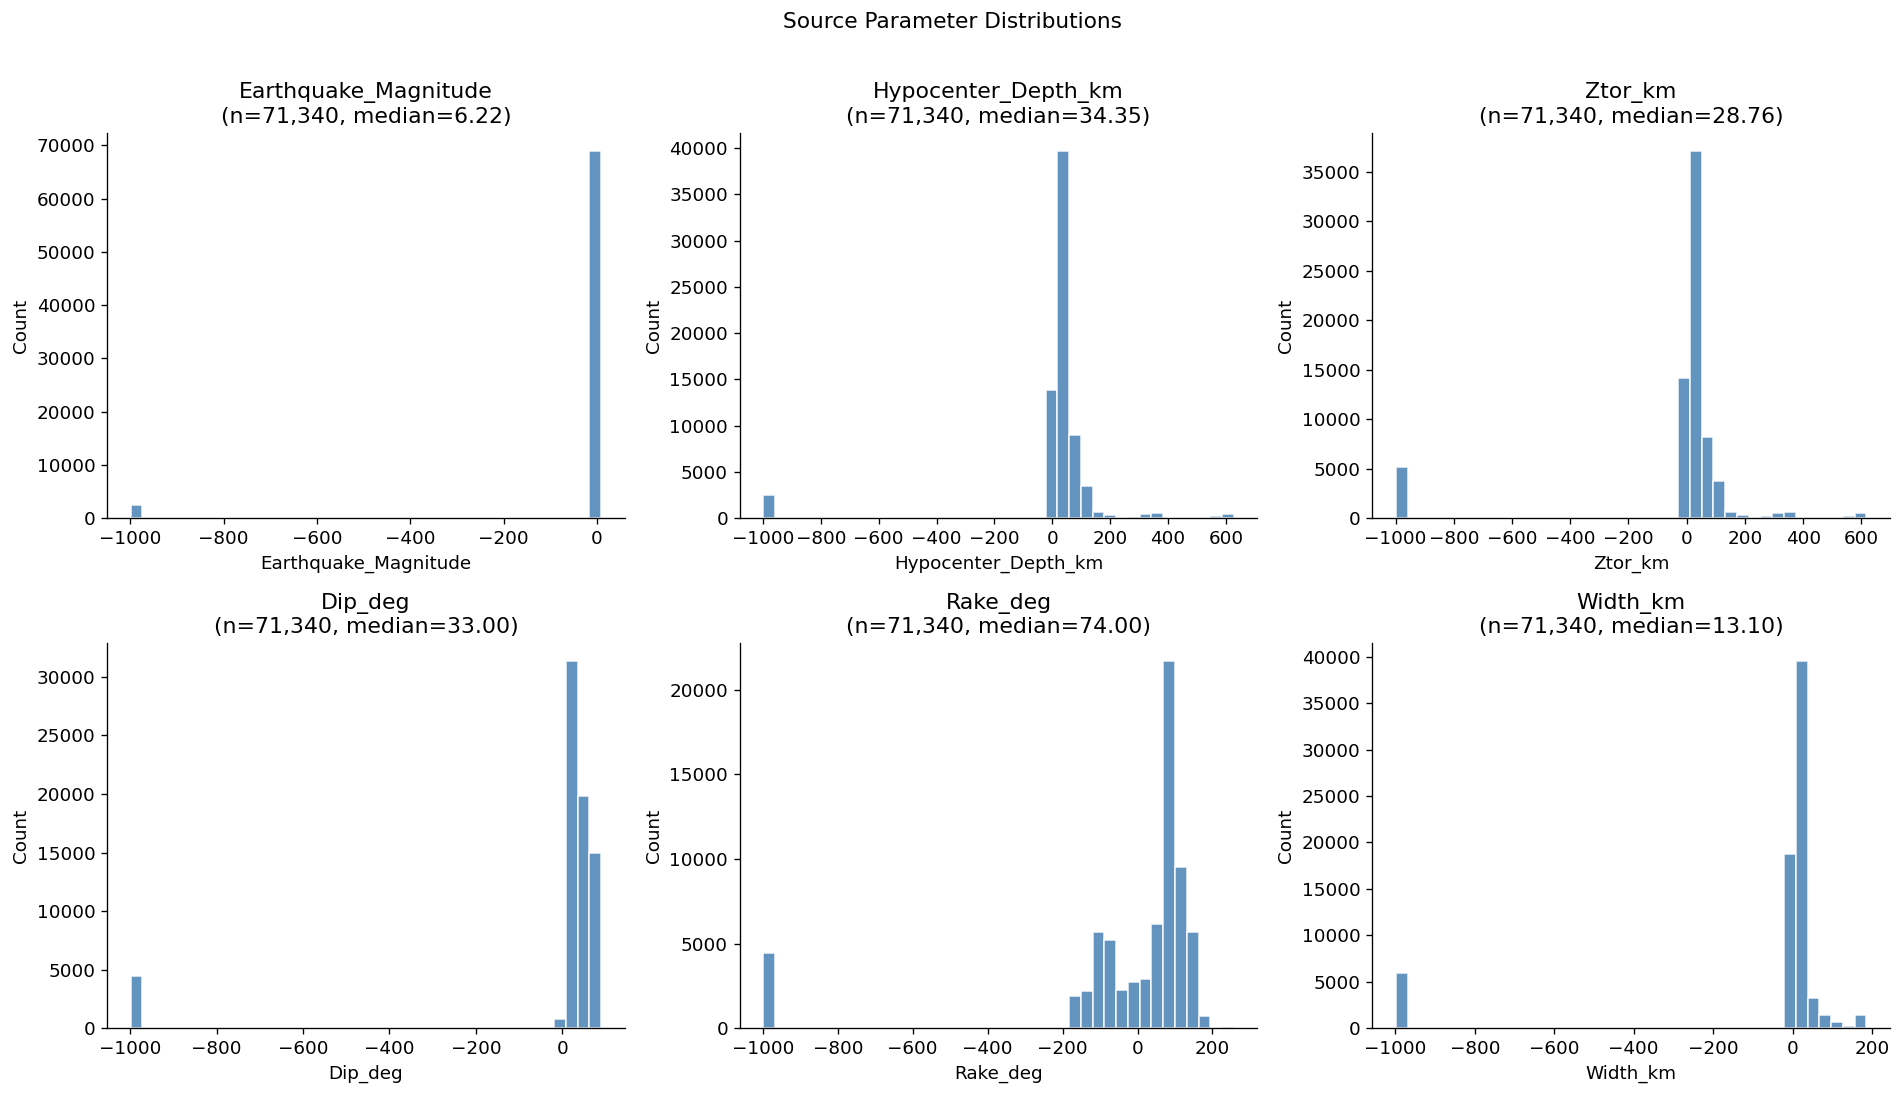

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

plot_src = ['Earthquake_Magnitude', 'Hypocenter_Depth_km', 'Ztor_km',
            'Dip_deg', 'Rake_deg', 'Width_km']
plot_src = [c for c in plot_src if c in df.columns]

for i, col in enumerate(plot_src):
    vals = df[col].dropna()
    axes[i].hist(vals, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].set_title(f'{col}\n(n={len(vals):,}, median={vals.median():.2f})')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Source Parameter Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

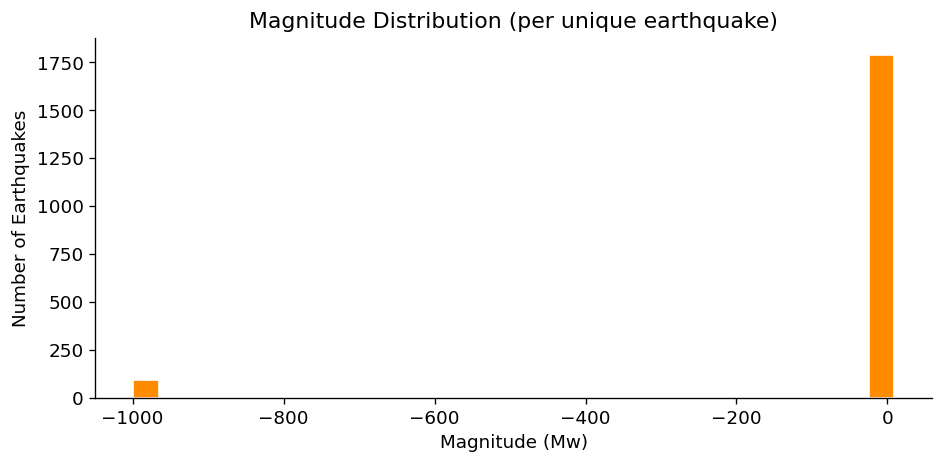

In [13]:
# Magnitude distribution per-event (one value per earthquake)
eq_df = df.drop_duplicates('NGAsubEQID')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(eq_df['Earthquake_Magnitude'].dropna(), bins=30, color='darkorange', edgecolor='white')
ax.set_xlabel('Magnitude (Mw)')
ax.set_ylabel('Number of Earthquakes')
ax.set_title('Magnitude Distribution (per unique earthquake)')
plt.tight_layout()
plt.show()

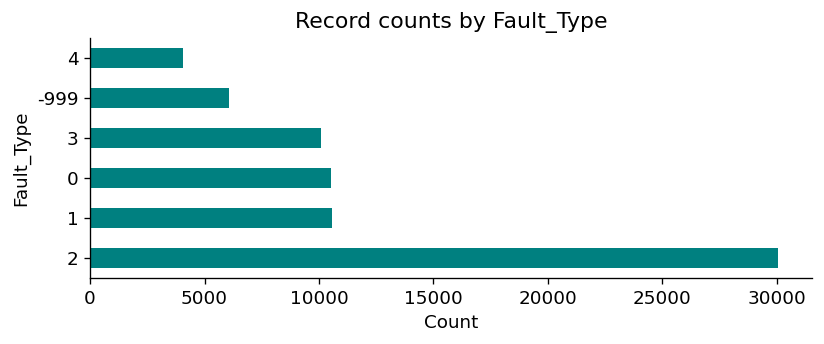

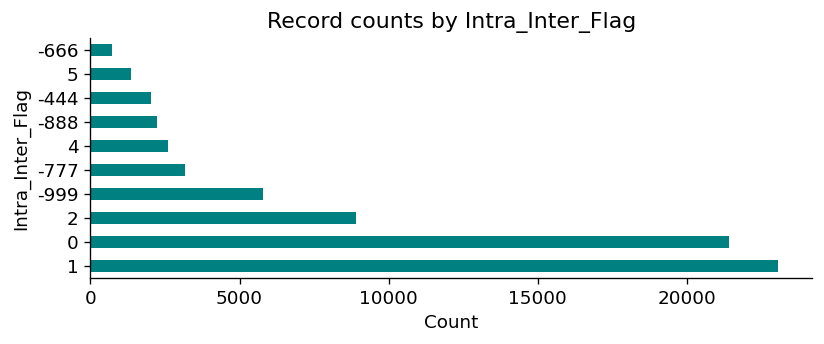

In [14]:
# Fault type / Interface-Intraslab breakdown
for col in ['Fault_Type', 'Intra_Inter_Flag']:
    if col in df.columns:
        vc = df[col].value_counts(dropna=False)
        fig, ax = plt.subplots(figsize=(7, 3))
        vc.plot.barh(ax=ax, color='teal')
        ax.set_title(f'Record counts by {col}')
        ax.set_xlabel('Count')
        plt.tight_layout()
        plt.show()

---
## 6. Path Parameter Distributions & Magnitude-Distance Coverage

**Why:** GMMs predict ground motion as a function of both magnitude and distance. Gaps or truncations in the M-R space will cause poor generalization. The M-R scatter plot is the most important coverage diagnostic.

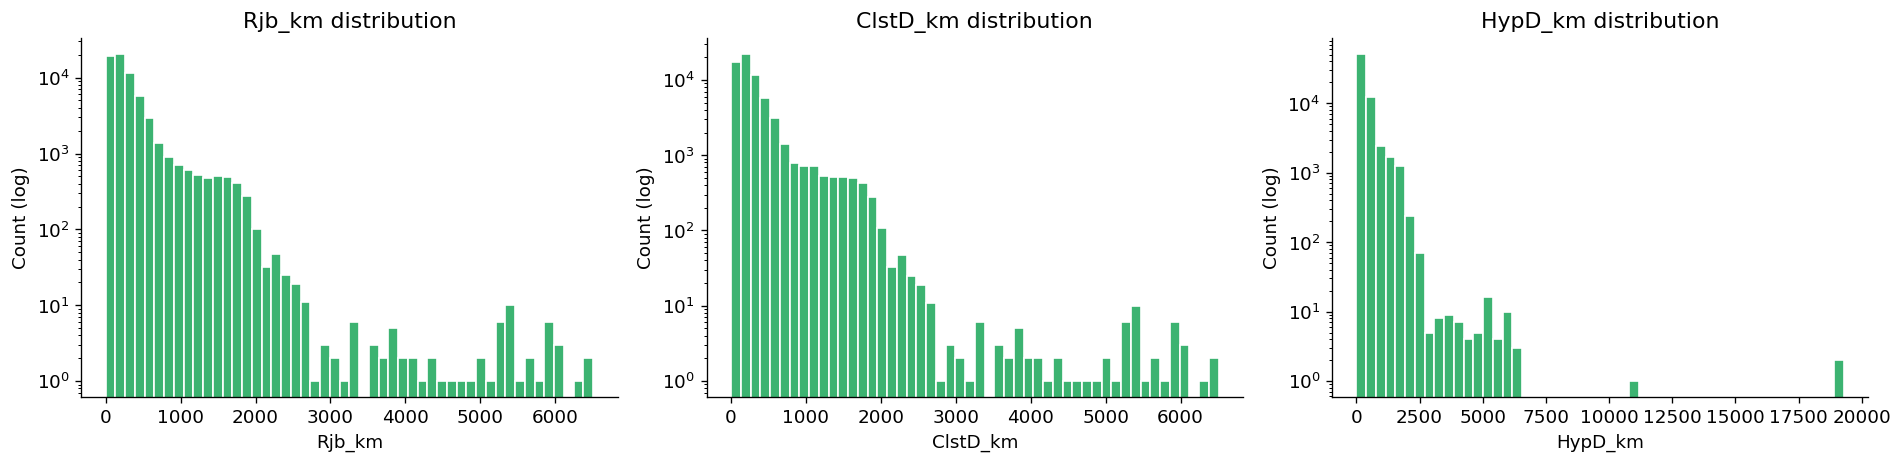

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(['Rjb_km', 'ClstD_km', 'HypD_km']):
    if col in df.columns:
        vals = df[col].dropna()
        axes[i].hist(vals[vals > 0], bins=50, color='mediumseagreen', edgecolor='white', log=True)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count (log)')
        axes[i].set_title(f'{col} distribution')

plt.tight_layout()
plt.show()

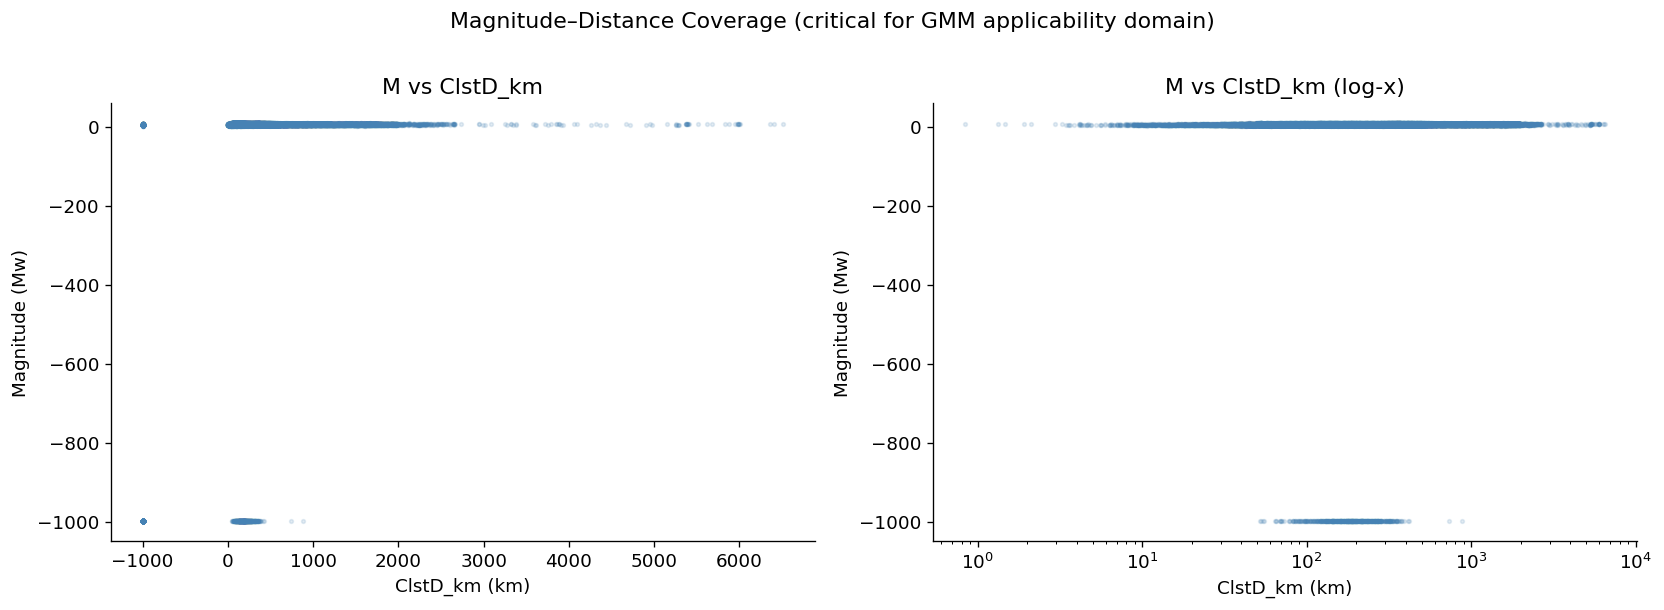

In [16]:
# M-R coverage map  (key diagnostic)
r_col = 'ClstD_km' if 'ClstD_km' in df.columns else 'Rjb_km'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, logx in zip(axes, [False, True]):
    ax.scatter(df[r_col], df['Earthquake_Magnitude'],
               alpha=0.15, s=5, color='steelblue', rasterized=True)
    ax.set_xlabel(f'{r_col} (km)')
    ax.set_ylabel('Magnitude (Mw)')
    ax.set_title(f'M vs {r_col}{" (log-x)" if logx else ""}')
    if logx:
        ax.set_xscale('log')

plt.suptitle('Magnitude–Distance Coverage (critical for GMM applicability domain)', y=1.01)
plt.tight_layout()
plt.show()

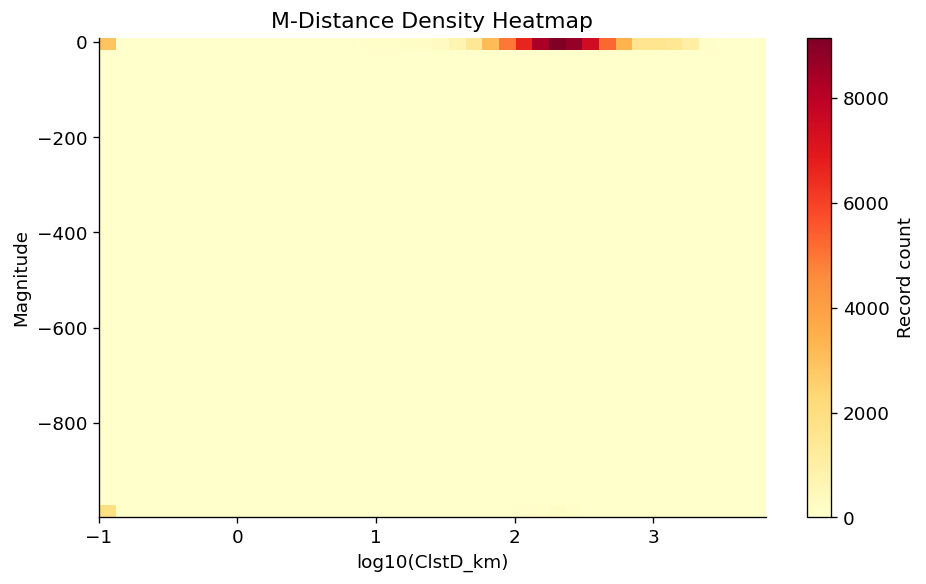

In [17]:
# 2D density — M vs distance
r_vals = df[r_col].dropna()
m_vals = df.loc[r_vals.index, 'Earthquake_Magnitude'].dropna()
common = r_vals.index.intersection(m_vals.index)

fig, ax = plt.subplots(figsize=(8, 5))
h = ax.hist2d(np.log10(df.loc[common, r_col].clip(lower=0.1)),
              df.loc[common, 'Earthquake_Magnitude'],
              bins=40, cmap='YlOrRd')
plt.colorbar(h[3], ax=ax, label='Record count')
ax.set_xlabel(f'log10({r_col})')
ax.set_ylabel('Magnitude')
ax.set_title('M-Distance Density Heatmap')
plt.tight_layout()
plt.show()

---
## 7. Site Parameter Analysis (Vs30, Basin Depths)

**Why:** Vs30 and basin depths (Z1.0, Z2.5) are the primary site amplification predictors. Checking their distributions, proportion of measured vs inferred Vs30, and cross-correlations with other site parameters is essential for understanding site-term complexity.

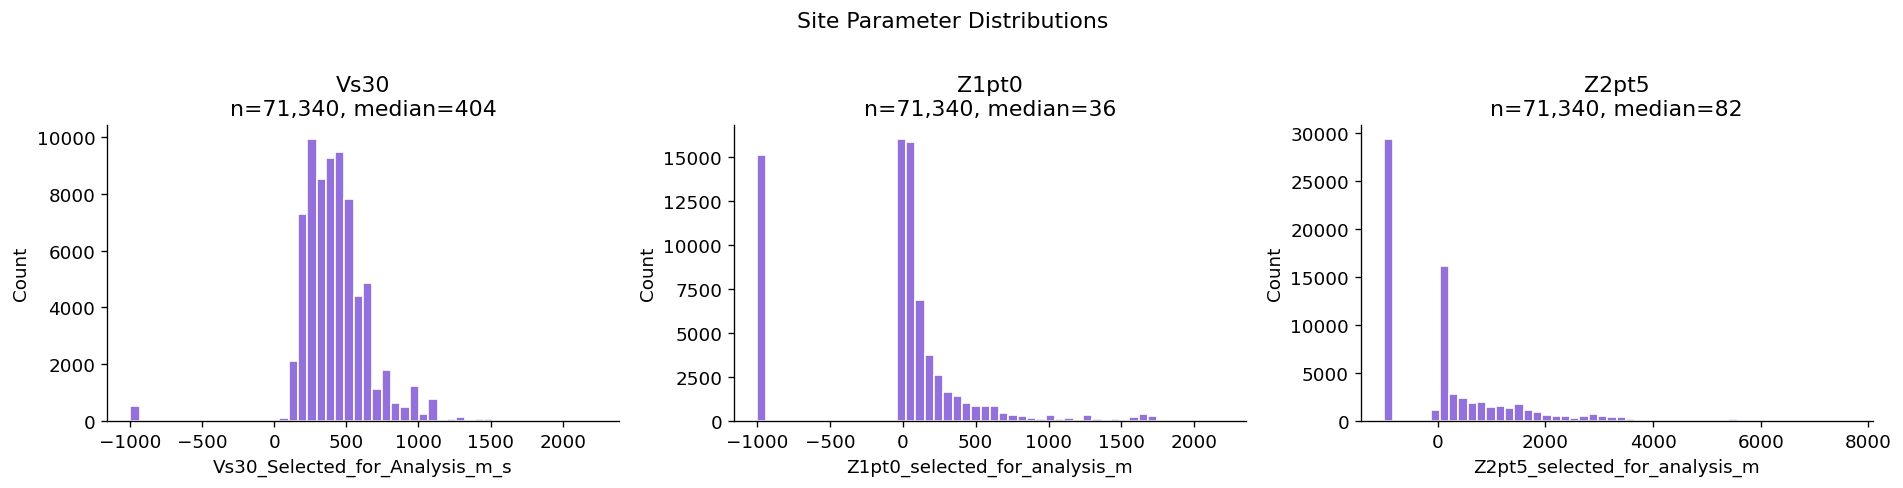

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(['Vs30_Selected_for_Analysis_m_s',
                          'Z1pt0_selected_for_analysis_m',
                          'Z2pt5_selected_for_analysis_m']):
    if col in df.columns:
        vals = df[col].dropna()
        axes[i].hist(vals, bins=50, color='mediumpurple', edgecolor='white')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].set_title(f'{col.split("_")[0]}\nn={len(vals):,}, median={vals.median():.0f}')

plt.suptitle('Site Parameter Distributions', y=1.01)
plt.tight_layout()
plt.show()

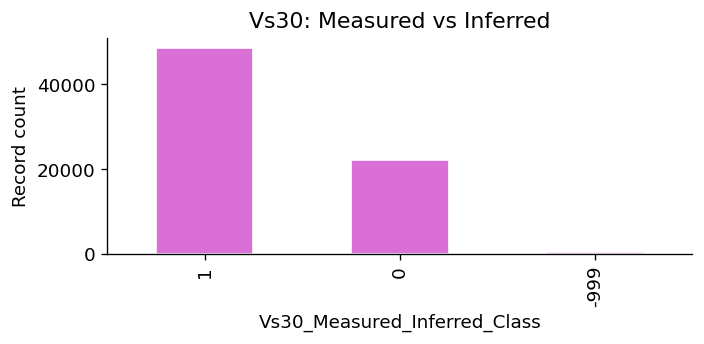

Vs30_Measured_Inferred_Class
 1      48618
 0      22183
-999      539
Name: count, dtype: int64


In [19]:
# Measured vs inferred Vs30 breakdown
if 'Vs30_Measured_Inferred_Class' in df.columns:
    vc = df['Vs30_Measured_Inferred_Class'].value_counts(dropna=False)
    fig, ax = plt.subplots(figsize=(6, 3))
    vc.plot.bar(ax=ax, color='orchid', edgecolor='white')
    ax.set_title('Vs30: Measured vs Inferred')
    ax.set_ylabel('Record count')
    plt.tight_layout()
    plt.show()
    print(vc)

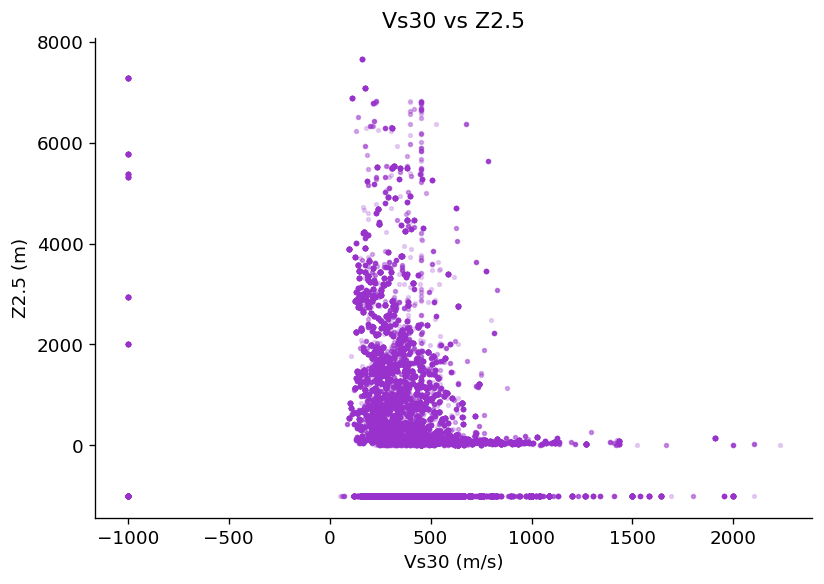

In [20]:
# Vs30 vs Z2.5 scatter — site proxy cross-check
if all(c in df.columns for c in ['Vs30_Selected_for_Analysis_m_s', 'Z2pt5_selected_for_analysis_m']):
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(df['Vs30_Selected_for_Analysis_m_s'],
               df['Z2pt5_selected_for_analysis_m'],
               alpha=0.2, s=5, color='darkorchid', rasterized=True)
    ax.set_xlabel('Vs30 (m/s)')
    ax.set_ylabel('Z2.5 (m)')
    ax.set_title('Vs30 vs Z2.5')
    plt.tight_layout()
    plt.show()

---
## 8. Response Variable Analysis — PGA, PGV, PGD

**Why:** GMM response variables should be approximately log-normally distributed. Checking PGA/PGV/PGD distributions, identifying physically implausible values (e.g., PGA > 3g), and looking at outliers helps set quality thresholds.

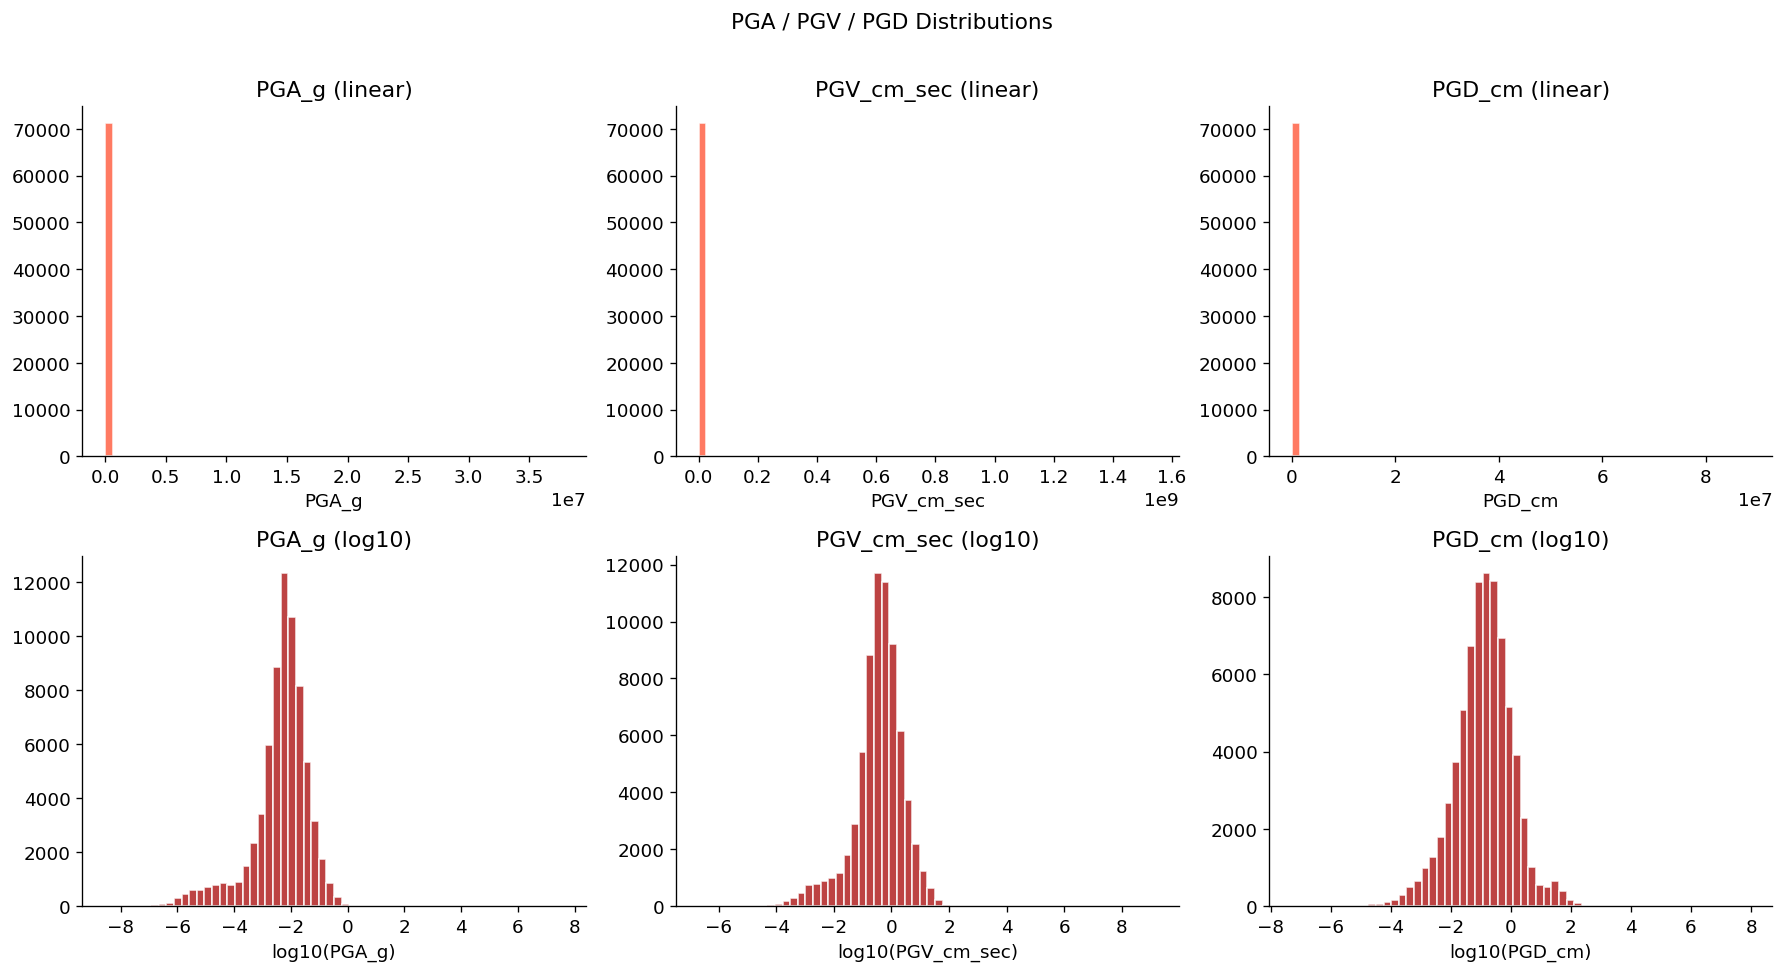

In [21]:
pgm_avail = [c for c in pgm_cols if c in df.columns]

fig, axes = plt.subplots(2, len(pgm_avail), figsize=(5*len(pgm_avail), 8))
if len(pgm_avail) == 1:
    axes = axes.reshape(2, 1)

for i, col in enumerate(pgm_avail):
    vals = df[col].dropna()
    vals_pos = vals[vals > 0]

    # Linear scale
    axes[0, i].hist(vals_pos, bins=60, color='tomato', edgecolor='white', alpha=0.85)
    axes[0, i].set_xlabel(col)
    axes[0, i].set_title(f'{col} (linear)')

    # Log scale
    axes[1, i].hist(np.log10(vals_pos), bins=60, color='firebrick', edgecolor='white', alpha=0.85)
    axes[1, i].set_xlabel(f'log10({col})')
    axes[1, i].set_title(f'{col} (log10)')

plt.suptitle('PGA / PGV / PGD Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [22]:
# Summary statistics for response variables
if pgm_avail:
    print(df[pgm_avail].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T)

              count          mean           std    min        1%        5%  \
PGA_g       71340.0   1771.978475  2.117309e+05 -999.0  0.000001  0.000024   
PGV_cm_sec  71340.0  84412.630283  9.236742e+06 -999.0  0.000544  0.006092   
PGD_cm      71340.0   6108.380672  5.872673e+05 -999.0  0.000270  0.002502   

                 25%       50%       75%       95%       99%           max  
PGA_g       0.001981  0.006148  0.016998  0.084183   0.26319  3.776100e+07  
PGV_cm_sec  0.158848  0.442065  1.198125  6.302220  21.57205  1.546000e+09  
PGD_cm      0.036978  0.141580  0.502443  3.637935  38.93200  8.851700e+07  


---
## 9. Spectral Acceleration (SA) Curves

**Why:** Examining the shape and spread of response spectra reveals whether the dataset captures the expected period-dependent behavior. Median ± percentile bands expose period ranges with sparse data or anomalous shapes.

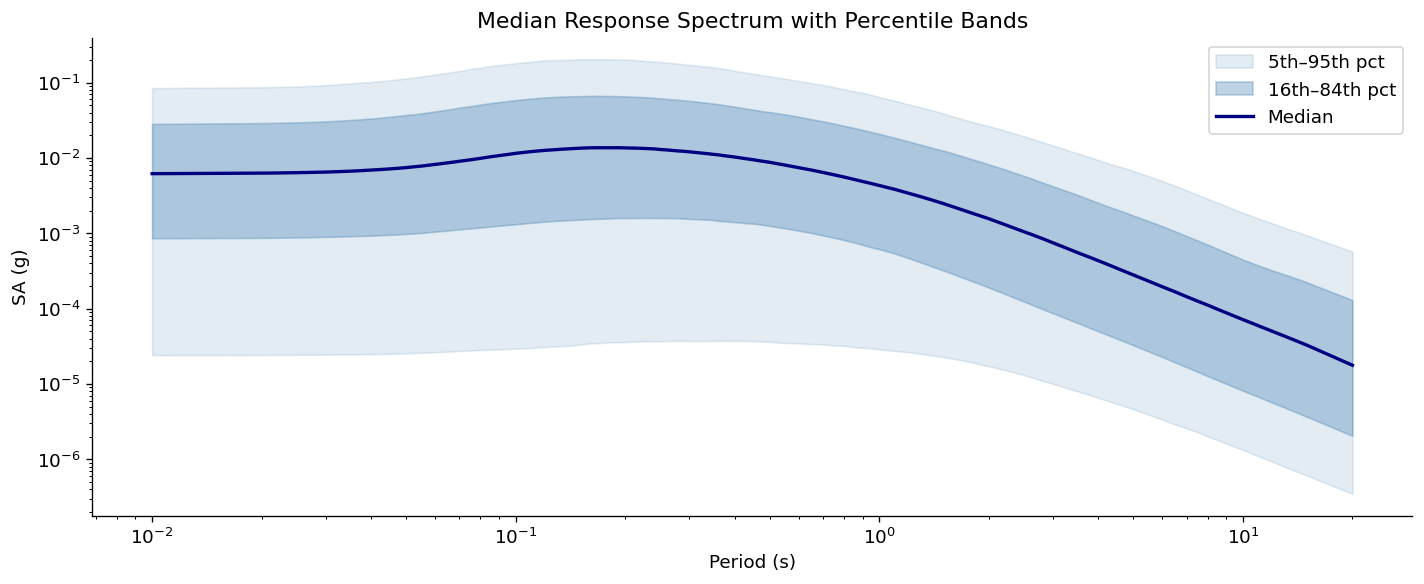

In [23]:
# Extract period values from column names
def col_to_period(col):
    """Convert column name like T0pt100S or T1pt500S to float period."""
    try:
        s = col.replace('T', '').replace('S', '').replace('pt', '.')
        return float(s)
    except:
        return None

periods = [col_to_period(c) for c in sa_cols]
valid = [(p, c) for p, c in zip(periods, sa_cols) if p is not None]
valid.sort(key=lambda x: x[0])
T_vals = [v[0] for v in valid]
sa_col_sorted = [v[1] for v in valid]

sa_data = df[sa_col_sorted].apply(pd.to_numeric, errors='coerce')

median_sa = sa_data.median()
p16_sa    = sa_data.quantile(0.16)
p84_sa    = sa_data.quantile(0.84)
p05_sa    = sa_data.quantile(0.05)
p95_sa    = sa_data.quantile(0.95)

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(T_vals, p05_sa, p95_sa, alpha=0.15, color='steelblue', label='5th–95th pct')
ax.fill_between(T_vals, p16_sa, p84_sa, alpha=0.35, color='steelblue', label='16th–84th pct')
ax.plot(T_vals, median_sa, color='navy', linewidth=2, label='Median')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Period (s)')
ax.set_ylabel('SA (g)')
ax.set_title('Median Response Spectrum with Percentile Bands')
ax.legend()
plt.tight_layout()
plt.show()

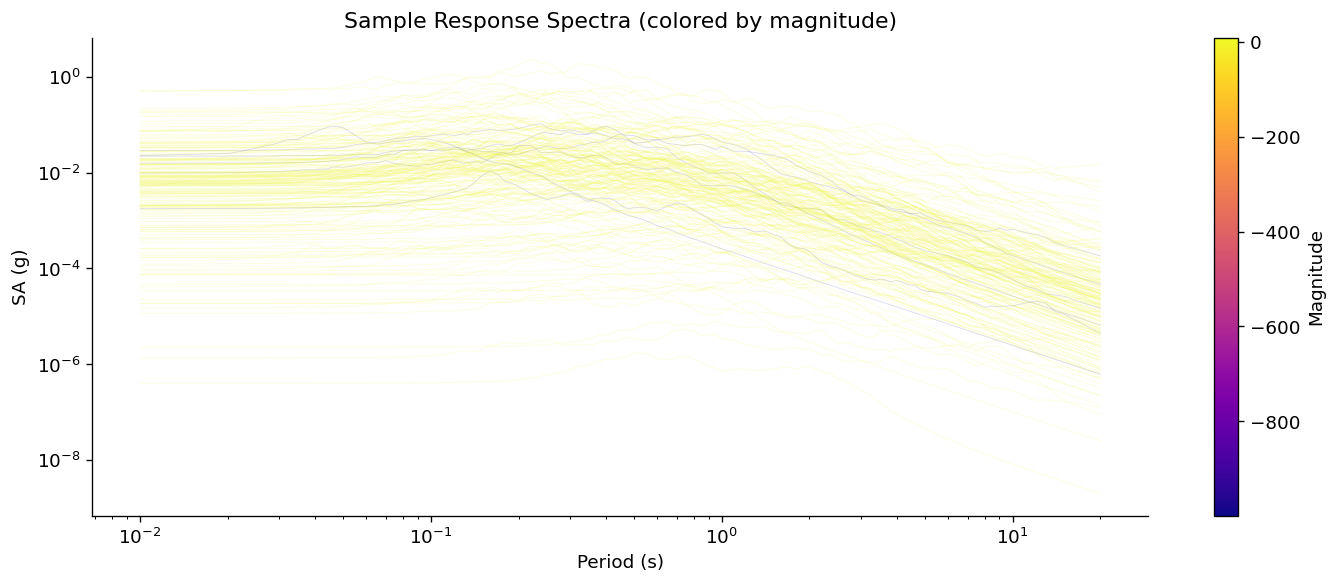

In [24]:
# Random sample of individual spectra  (color by magnitude)
sample_idx = df.sample(min(200, len(df)), random_state=42).index
mags = df.loc[sample_idx, 'Earthquake_Magnitude']
norm = plt.Normalize(mags.min(), mags.max())
cmap = plt.cm.plasma

fig, ax = plt.subplots(figsize=(12, 5))
for idx in sample_idx:
    row = sa_data.loc[idx]
    m   = df.loc[idx, 'Earthquake_Magnitude']
    if pd.notnull(m):
        ax.plot(T_vals, row.values, alpha=0.15, linewidth=0.5, color=cmap(norm(m)))

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Magnitude')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Period (s)')
ax.set_ylabel('SA (g)')
ax.set_title('Sample Response Spectra (colored by magnitude)')
plt.tight_layout()
plt.show()

---
## 10. SA Attenuation with Distance

**Why:** A GMM's core relationship is ground motion attenuation with distance. Plotting log(SA) vs log(distance) at selected periods visually confirms the expected negative trend and magnitude stratification.

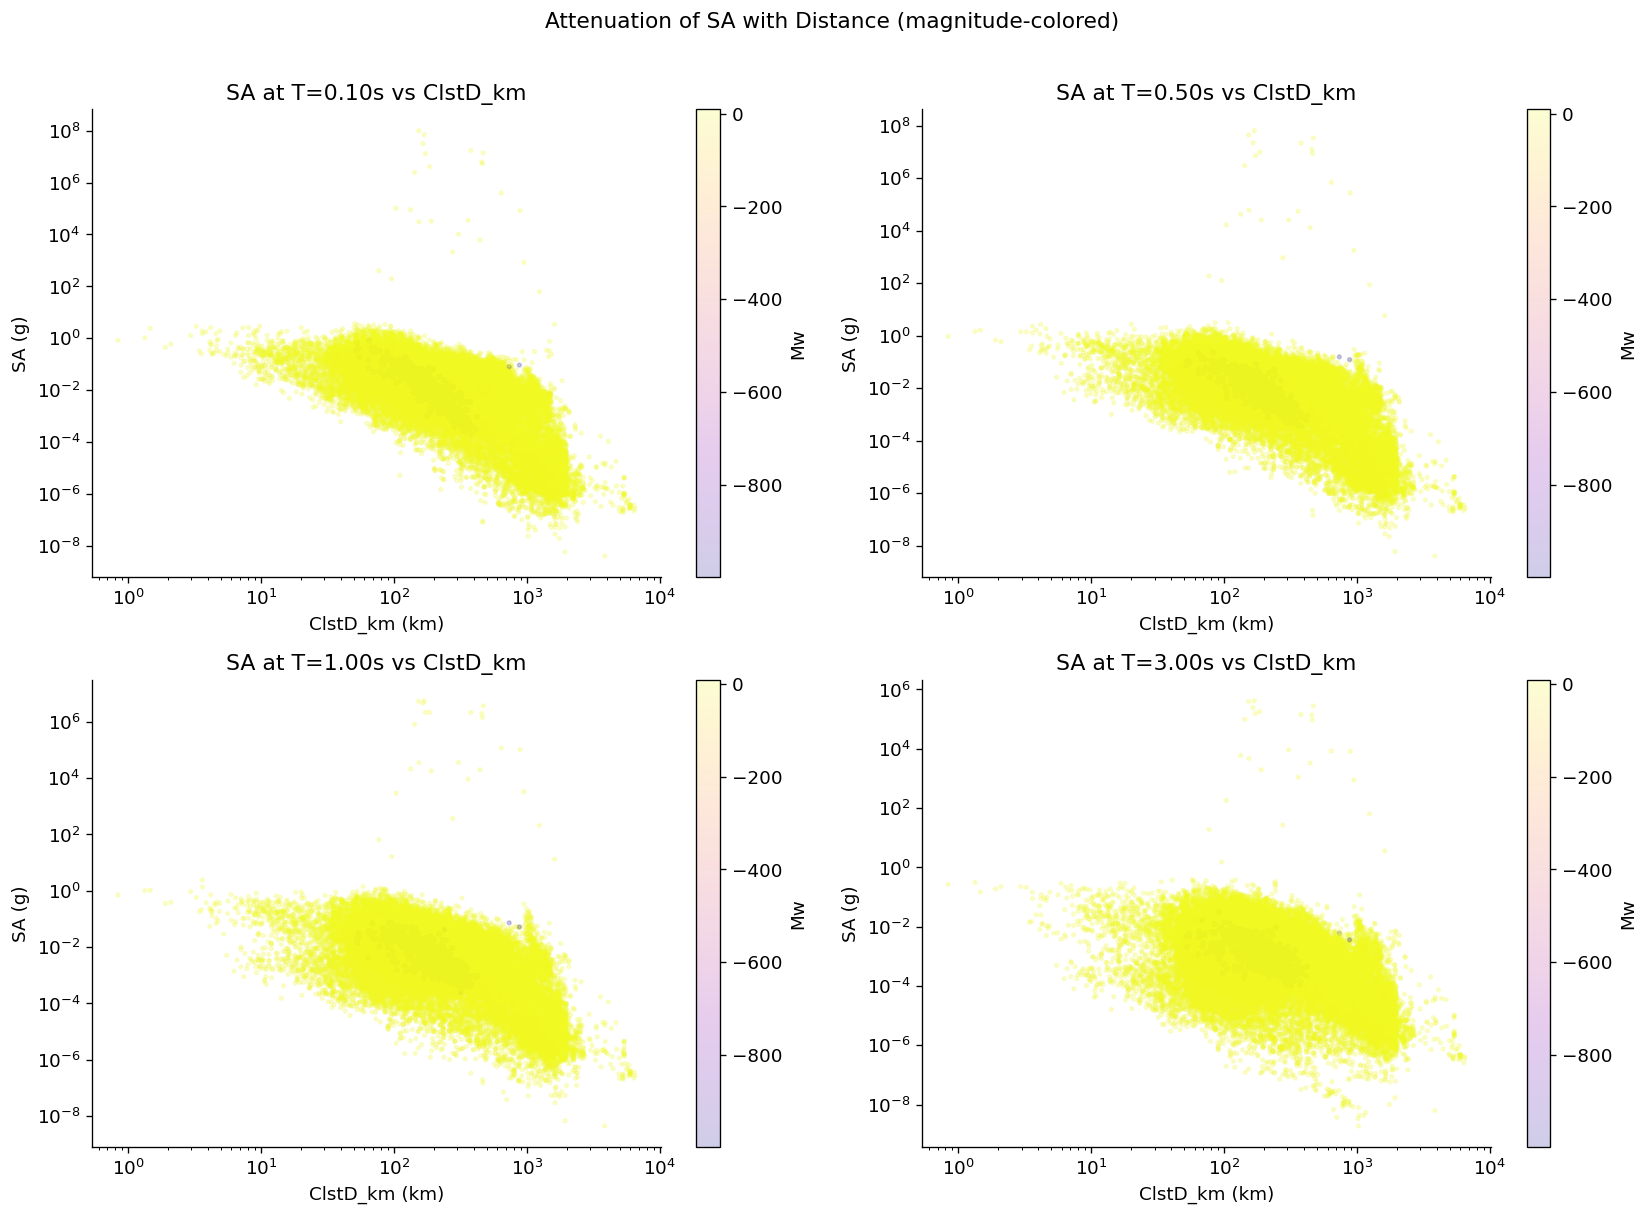

In [25]:
check_periods = [0.1, 0.5, 1.0, 3.0]  # seconds
r_col = 'ClstD_km' if 'ClstD_km' in df.columns else 'Rjb_km'

def nearest_col(target_T):
    diffs = [abs(t - target_T) for t in T_vals]
    idx = np.argmin(diffs)
    return sa_col_sorted[idx], T_vals[idx]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, T in enumerate(check_periods):
    col, actual_T = nearest_col(T)
    mask = df[r_col].notna() & df[col].notna() & df['Earthquake_Magnitude'].notna() & (df[r_col] > 0) & (df[col] > 0)
    sub = df[mask].copy()

    sc = axes[i].scatter(sub[r_col], sub[col],
                          c=sub['Earthquake_Magnitude'], cmap='plasma',
                          alpha=0.2, s=5, rasterized=True)
    plt.colorbar(sc, ax=axes[i], label='Mw')
    axes[i].set_xscale('log')
    axes[i].set_yscale('log')
    axes[i].set_xlabel(f'{r_col} (km)')
    axes[i].set_ylabel(f'SA (g)')
    axes[i].set_title(f'SA at T={actual_T:.2f}s vs {r_col}')

plt.suptitle('Attenuation of SA with Distance (magnitude-colored)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

---
## 11. Magnitude Scaling of SA

**Why:** GMMs must capture how ground motion scales with magnitude at each period. Plotting log(SA) vs Mw at fixed distance bins shows whether the scaling is linear in log-space and whether saturation effects (at short periods) are visible.

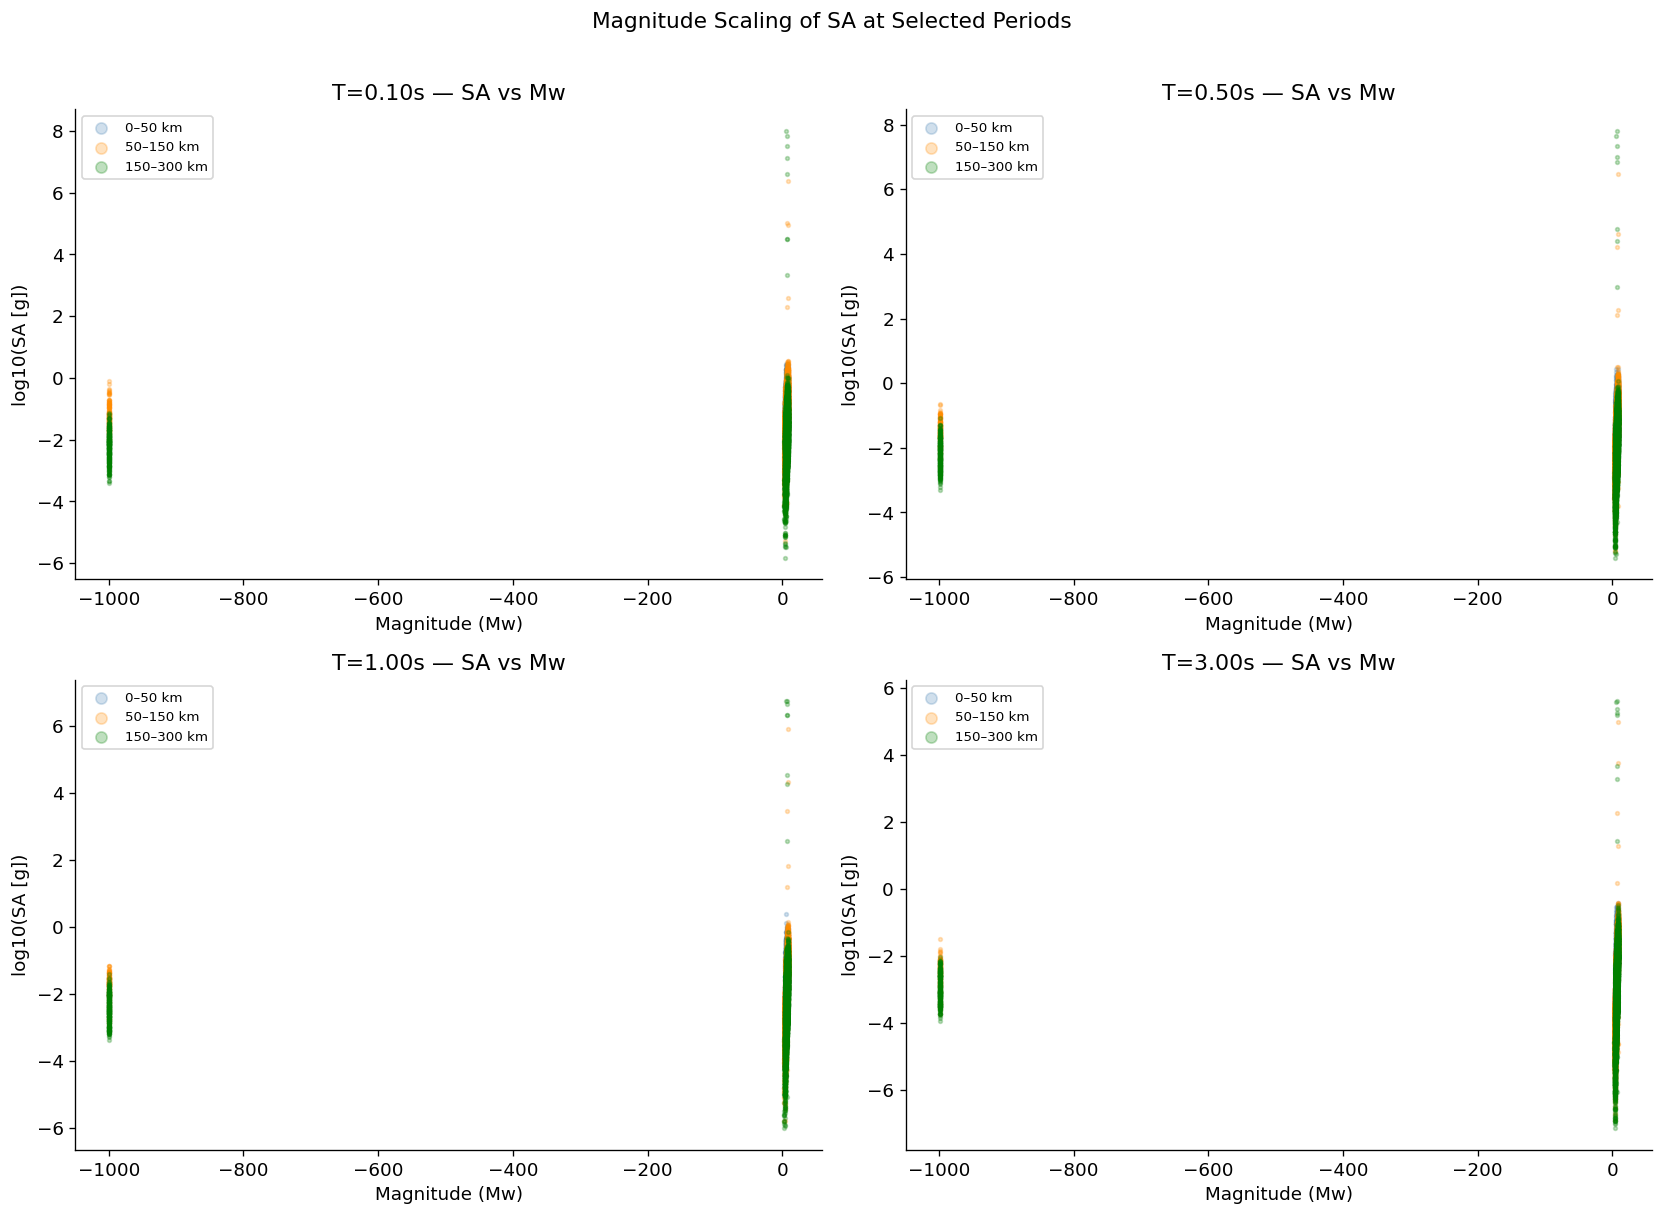

In [26]:
# Distance bins for stratification
dist_bins = [(0, 50), (50, 150), (150, 300)]
r_col = 'ClstD_km' if 'ClstD_km' in df.columns else 'Rjb_km'

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, T in enumerate(check_periods):
    col, actual_T = nearest_col(T)
    for (rlo, rhi), color in zip(dist_bins, ['steelblue', 'darkorange', 'green']):
        mask = (df[r_col] >= rlo) & (df[r_col] < rhi) & df[col].notna() & (df[col] > 0)
        sub = df[mask]
        axes[i].scatter(sub['Earthquake_Magnitude'], np.log10(sub[col]),
                        alpha=0.25, s=5, color=color,
                        label=f'{rlo}–{rhi} km', rasterized=True)
    axes[i].set_xlabel('Magnitude (Mw)')
    axes[i].set_ylabel('log10(SA [g])')
    axes[i].set_title(f'T={actual_T:.2f}s — SA vs Mw')
    axes[i].legend(fontsize=8, markerscale=3)

plt.suptitle('Magnitude Scaling of SA at Selected Periods', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

---
## 12. Vs30 Site Amplification

**Why:** Site amplification (Vs30 effect) is a key GMM component. Binning records by Vs30 and comparing SA medians reveals amplification patterns and confirms that the data can constrain a site term.

Vs30_Class
<180 (SE)         3518
180–360 (SD)     24983
360–760 (SC)     37557
760–1500 (SB)     4513
>1500 (SA)         230
Name: count, dtype: int64


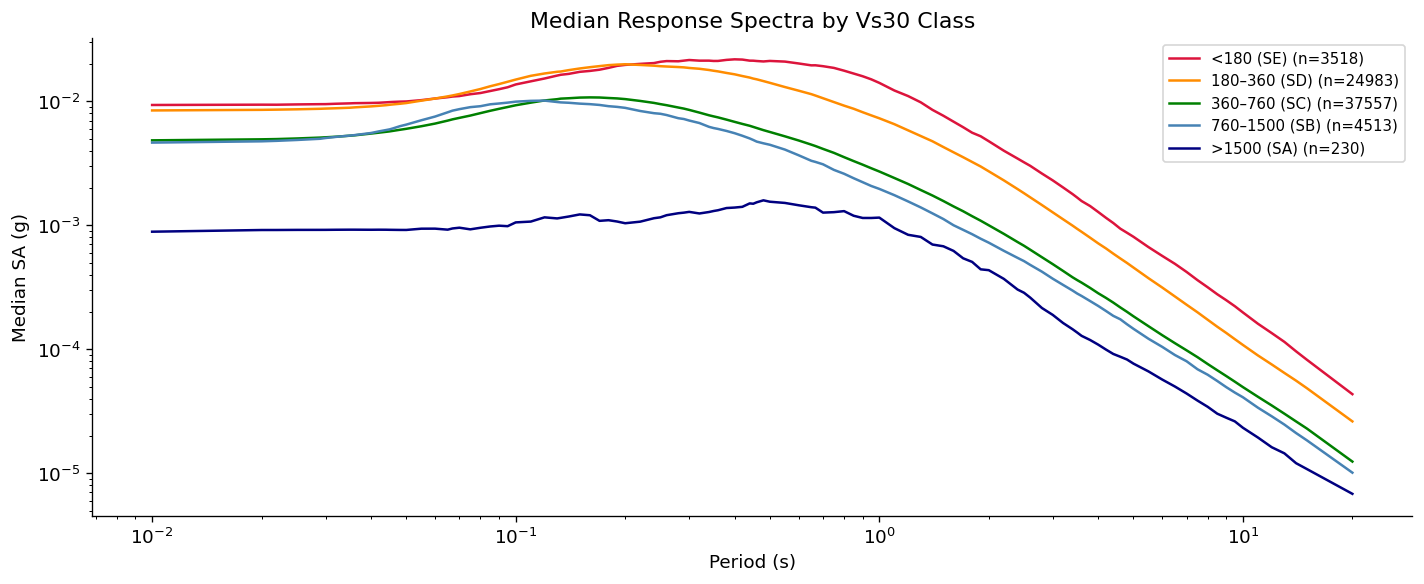

In [27]:
vs30_col = 'Vs30_Selected_for_Analysis_m_s'

if vs30_col in df.columns:
    # Bin Vs30
    vs30_bins = [0, 180, 360, 760, 1500, 99999]
    vs30_labels = ['<180 (SE)', '180–360 (SD)', '360–760 (SC)', '760–1500 (SB)', '>1500 (SA)']
    df['Vs30_Class'] = pd.cut(df[vs30_col], bins=vs30_bins, labels=vs30_labels)

    print(df['Vs30_Class'].value_counts().sort_index())

    # Median spectra by Vs30 class
    fig, ax = plt.subplots(figsize=(12, 5))
    colors_vs = ['crimson', 'darkorange', 'green', 'steelblue', 'navy']
    for cls, col in zip(vs30_labels, colors_vs):
        sub = df[df['Vs30_Class'] == cls]
        if len(sub) < 5:
            continue
        med = sub[sa_col_sorted].median()
        ax.plot(T_vals, med.values, label=f'{cls} (n={len(sub)})', color=col)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Period (s)')
    ax.set_ylabel('Median SA (g)')
    ax.set_title('Median Response Spectra by Vs30 Class')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

---
## 13. Interface vs Intraslab Comparison

**Why:** Subduction zone GMMs differentiate between interface (interplate) and intraslab (intraplate) events. They have distinct magnitude scaling, geometric spreading, and attenuation characteristics. Verifying the flag and comparing their median spectra is mandatory.

Event type distribution:
Intra_Inter_Flag
 1      23066
 0      21436
 2       8913
-999     5783
-777     3173
 4       2593
-888     2242
-444     2040
 5       1364
-666      730
Name: count, dtype: int64


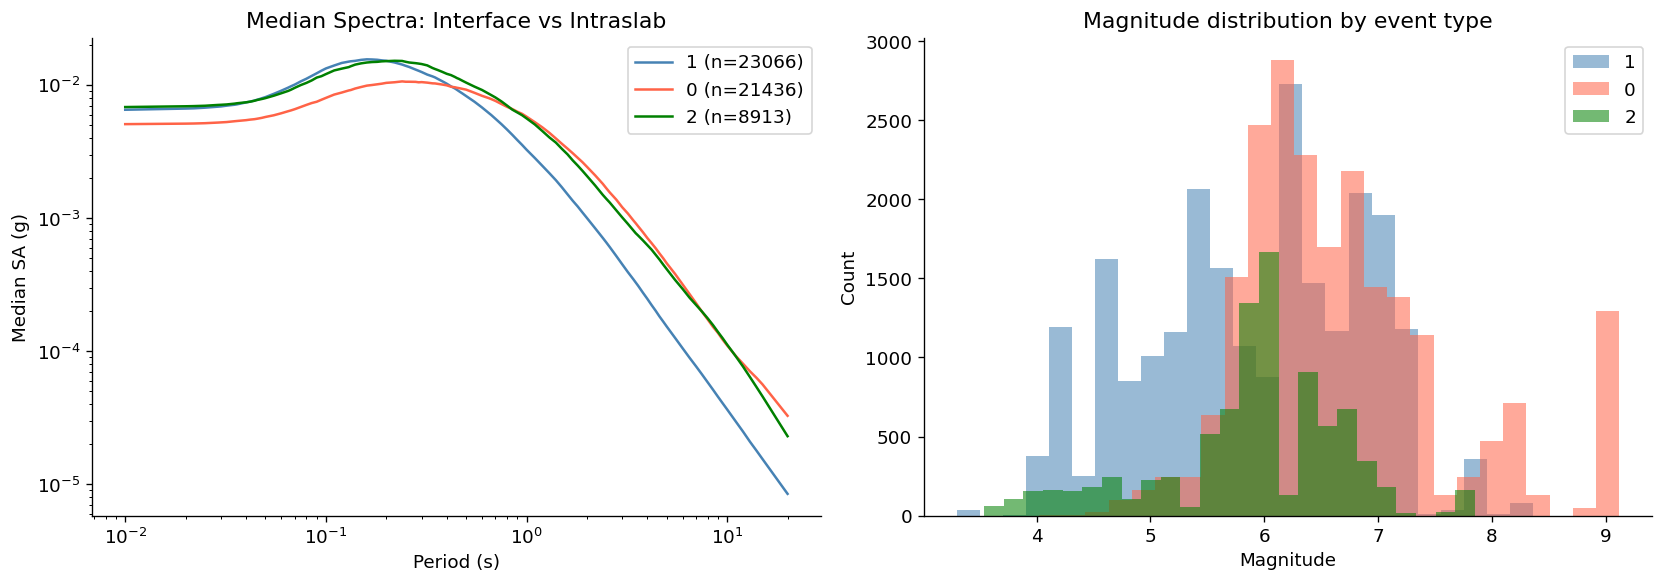

In [28]:
flag_col = 'Intra_Inter_Flag'

if flag_col in df.columns:
    print('Event type distribution:')
    print(df[flag_col].value_counts(dropna=False))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Median spectra
    for label, color in zip(df[flag_col].dropna().unique(), ['steelblue', 'tomato', 'green']):
        sub = df[df[flag_col] == label]
        med = sub[sa_col_sorted].median()
        axes[0].plot(T_vals, med.values, label=f'{label} (n={len(sub)})', color=color)
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    axes[0].set_xlabel('Period (s)')
    axes[0].set_ylabel('Median SA (g)')
    axes[0].set_title('Median Spectra: Interface vs Intraslab')
    axes[0].legend()

    # M distribution by type
    for label, color in zip(df[flag_col].dropna().unique(), ['steelblue', 'tomato', 'green']):
        sub = df[df[flag_col] == label]['Earthquake_Magnitude'].dropna()
        axes[1].hist(sub, bins=25, alpha=0.55, label=label, color=color)
    axes[1].set_xlabel('Magnitude')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Magnitude distribution by event type')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

---
## 14. Outlier & Data Quality Checks

**Why:** Outlier records can disproportionately influence GMM regression. We flag physically implausible values, check for negative distances, duplicate RSNs, and unrealistic Vs30 values.

In [29]:
issues = {}

# Duplicate RSN
dup_rsn = df['NGAsubRSN'].duplicated().sum() if 'NGAsubRSN' in df.columns else 0
issues['Duplicate RSN'] = dup_rsn

# Negative or zero distances
for col in path_cols:
    n_neg = (df[col] <= 0).sum()
    if n_neg > 0:
        issues[f'{col} ≤ 0'] = int(n_neg)

# Implausible Vs30
if 'Vs30_Selected_for_Analysis_m_s' in df.columns:
    issues['Vs30 < 50 m/s'] = int((df['Vs30_Selected_for_Analysis_m_s'] < 50).sum())
    issues['Vs30 > 3000 m/s'] = int((df['Vs30_Selected_for_Analysis_m_s'] > 3000).sum())

# PGA > 3g
if 'PGA_g' in df.columns:
    issues['PGA > 3 g'] = int((df['PGA_g'] > 3).sum())

# Magnitude out of range
issues['Magnitude < 4'] = int((df['Earthquake_Magnitude'] < 4).sum())
issues['Magnitude > 10'] = int((df['Earthquake_Magnitude'] > 10).sum())

# Depth < 0
if 'Hypocenter_Depth_km' in df.columns:
    issues['Depth < 0 km'] = int((df['Hypocenter_Depth_km'] < 0).sum())

print('Quality check summary:')
for k, v in issues.items():
    flag = '  ⚠️' if v > 0 else '  ✓'
    print(f'{flag}  {k}: {v}')

Quality check summary:
  ✓  Duplicate RSN: 0
  ⚠️  EpiD_km ≤ 0: 2194
  ⚠️  HypD_km ≤ 0: 2194
  ⚠️  Rjb_km ≤ 0: 4909
  ⚠️  ClstD_km ≤ 0: 4817
  ⚠️  Rrms_km ≤ 0: 10297
  ⚠️  Rx_km ≤ 0: 28884
  ⚠️  Ry_km ≤ 0: 39942
  ⚠️  Ry0_km ≤ 0: 41276
  ⚠️  RmaxForAnalysis_km ≤ 0: 4835
  ⚠️  Vs30 < 50 m/s: 539
  ✓  Vs30 > 3000 m/s: 0
  ⚠️  PGA > 3 g: 26
  ⚠️  Magnitude < 4: 2867
  ✓  Magnitude > 10: 0
  ⚠️  Depth < 0 km: 2473


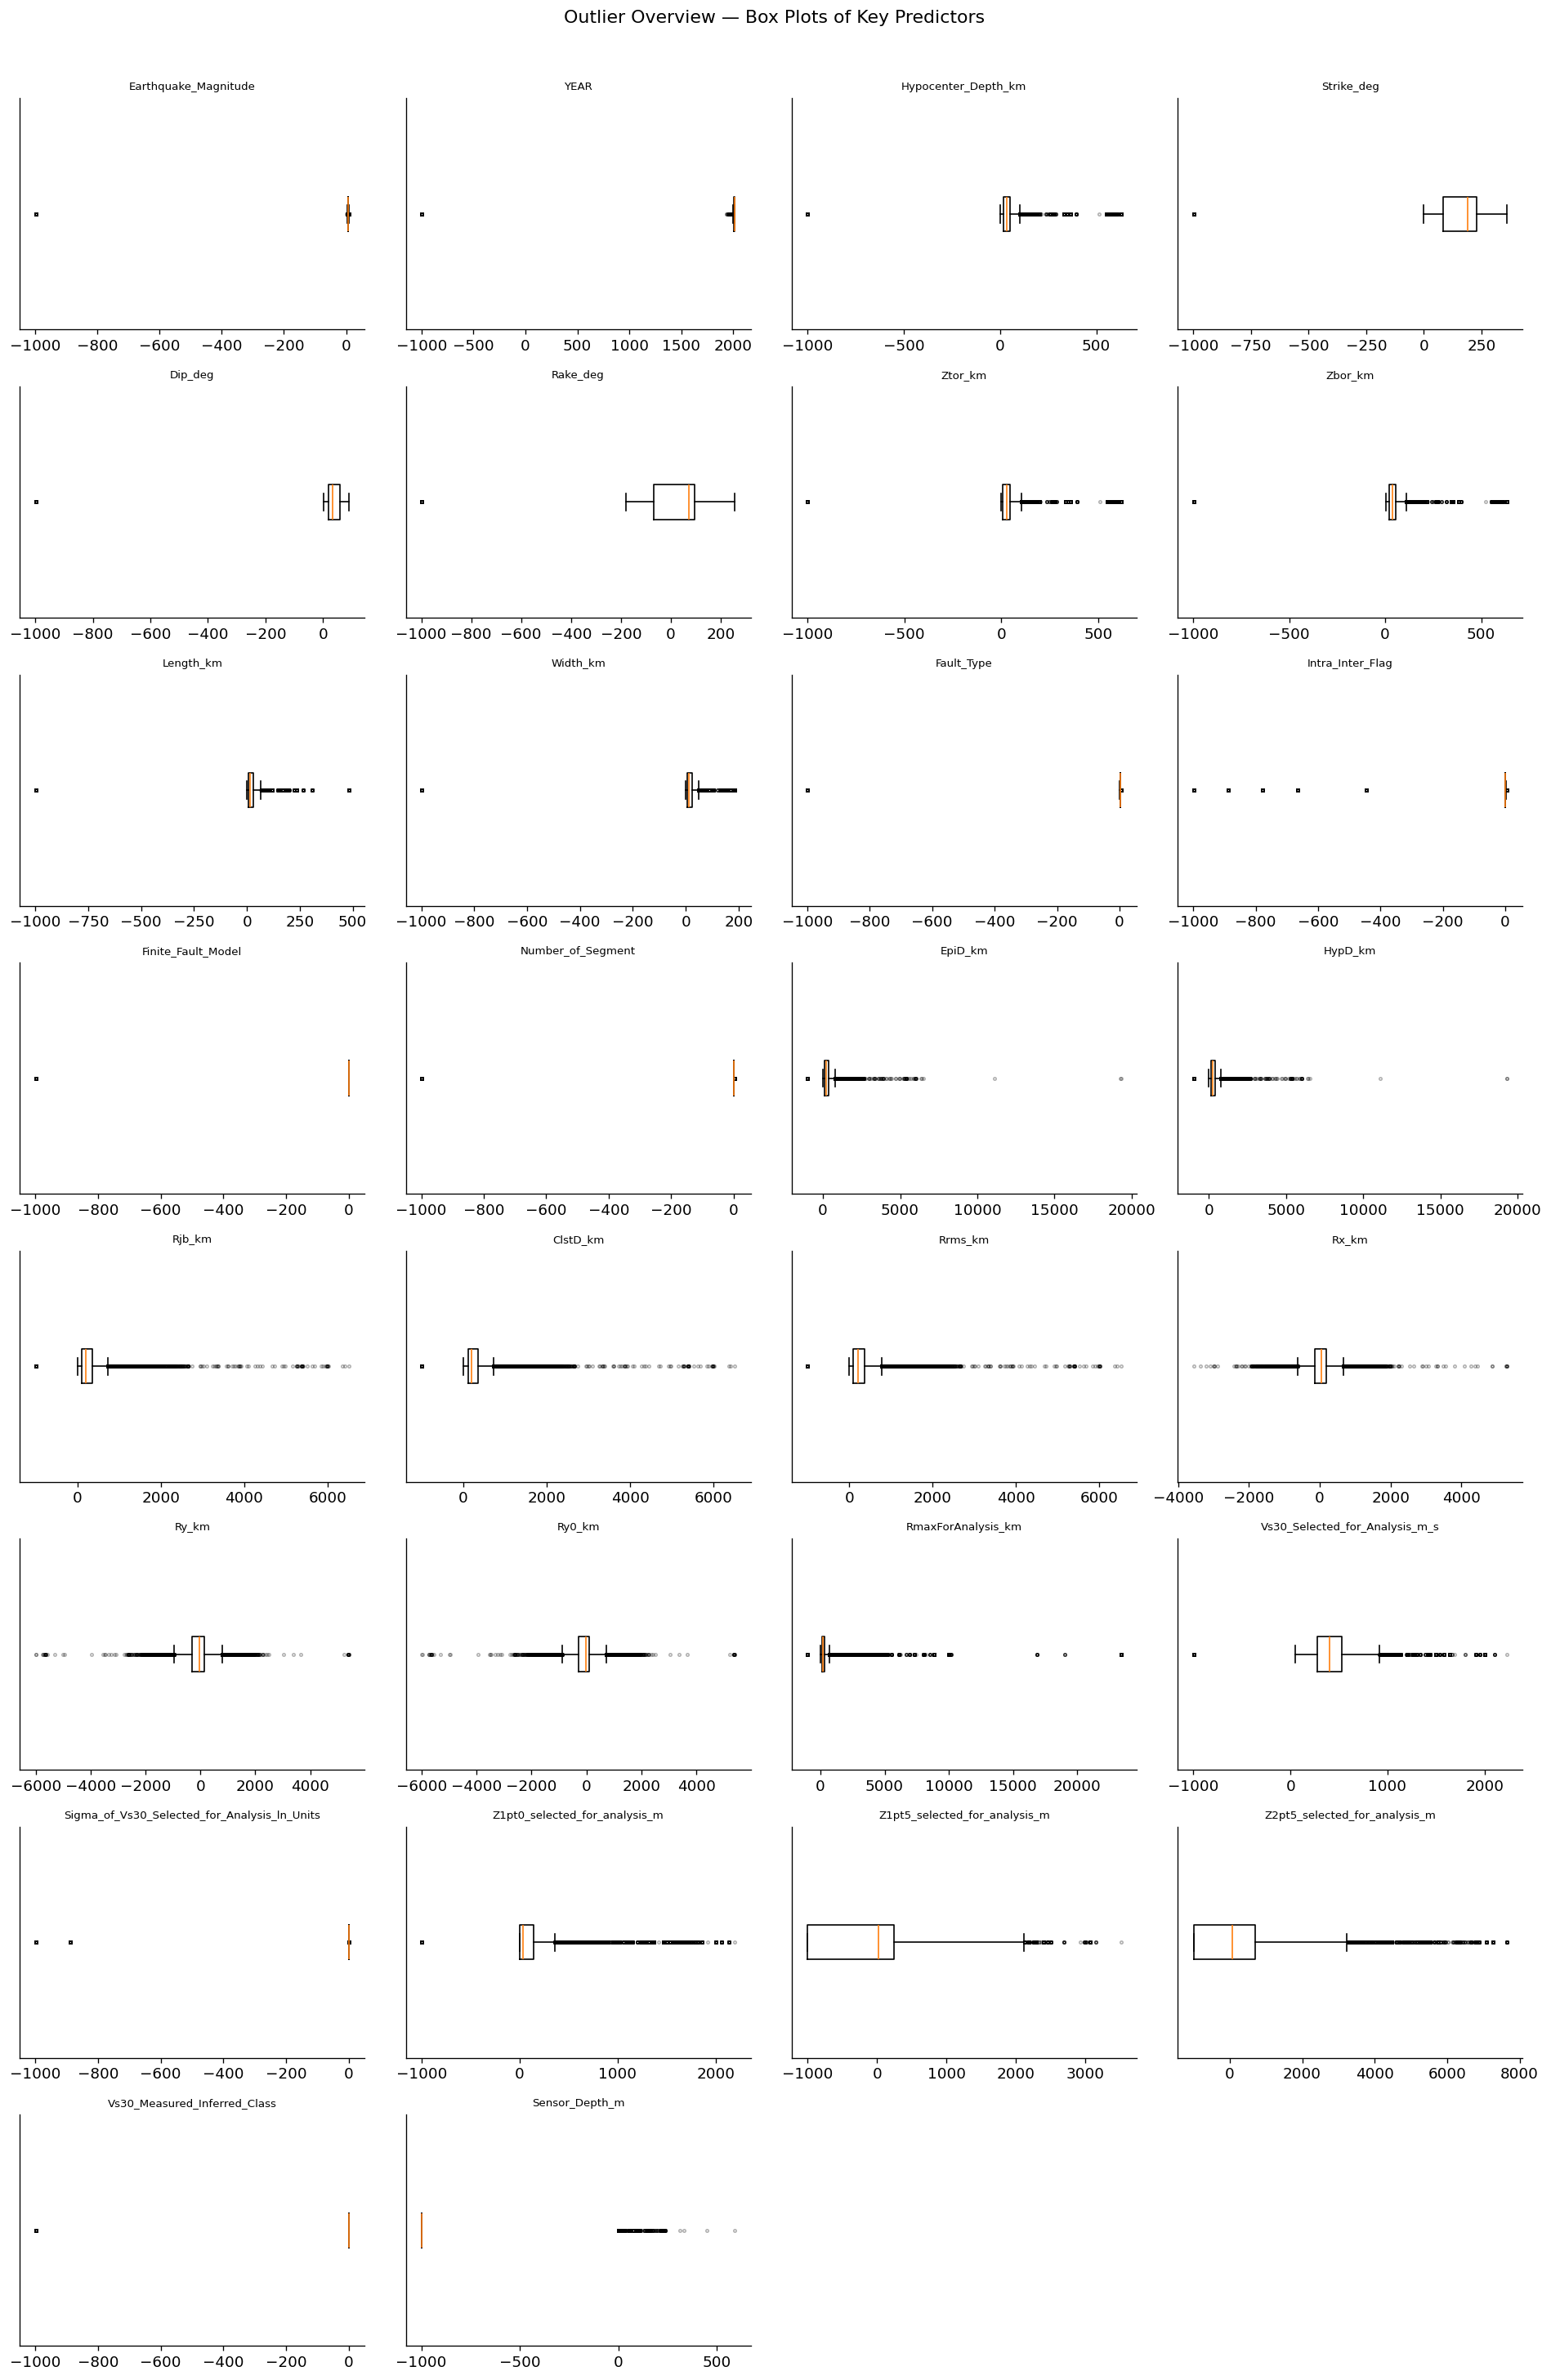

In [30]:
# Box-plots of key predictors to visualise outlier spread
numeric_key = [c for c in source_cols + path_cols + site_cols
               if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]

n_cols = 4
n_rows = (len(numeric_key) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3*n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_key):
    axes[i].boxplot(df[col].dropna(), vert=False, flierprops={'markersize': 2, 'alpha': 0.3})
    axes[i].set_title(col, fontsize=8)
    axes[i].set_yticks([])

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Outlier Overview — Box Plots of Key Predictors', y=1.01)
plt.tight_layout()
plt.show()

---
## 15. Correlation Analysis

**Why:** Correlated predictors (e.g., Rjb ≈ Rrup for shallow events; Vs30 and Z2.5) create multicollinearity that can destabilize GMM regression coefficients. Identifying high correlations guides predictor selection or regularization strategy.

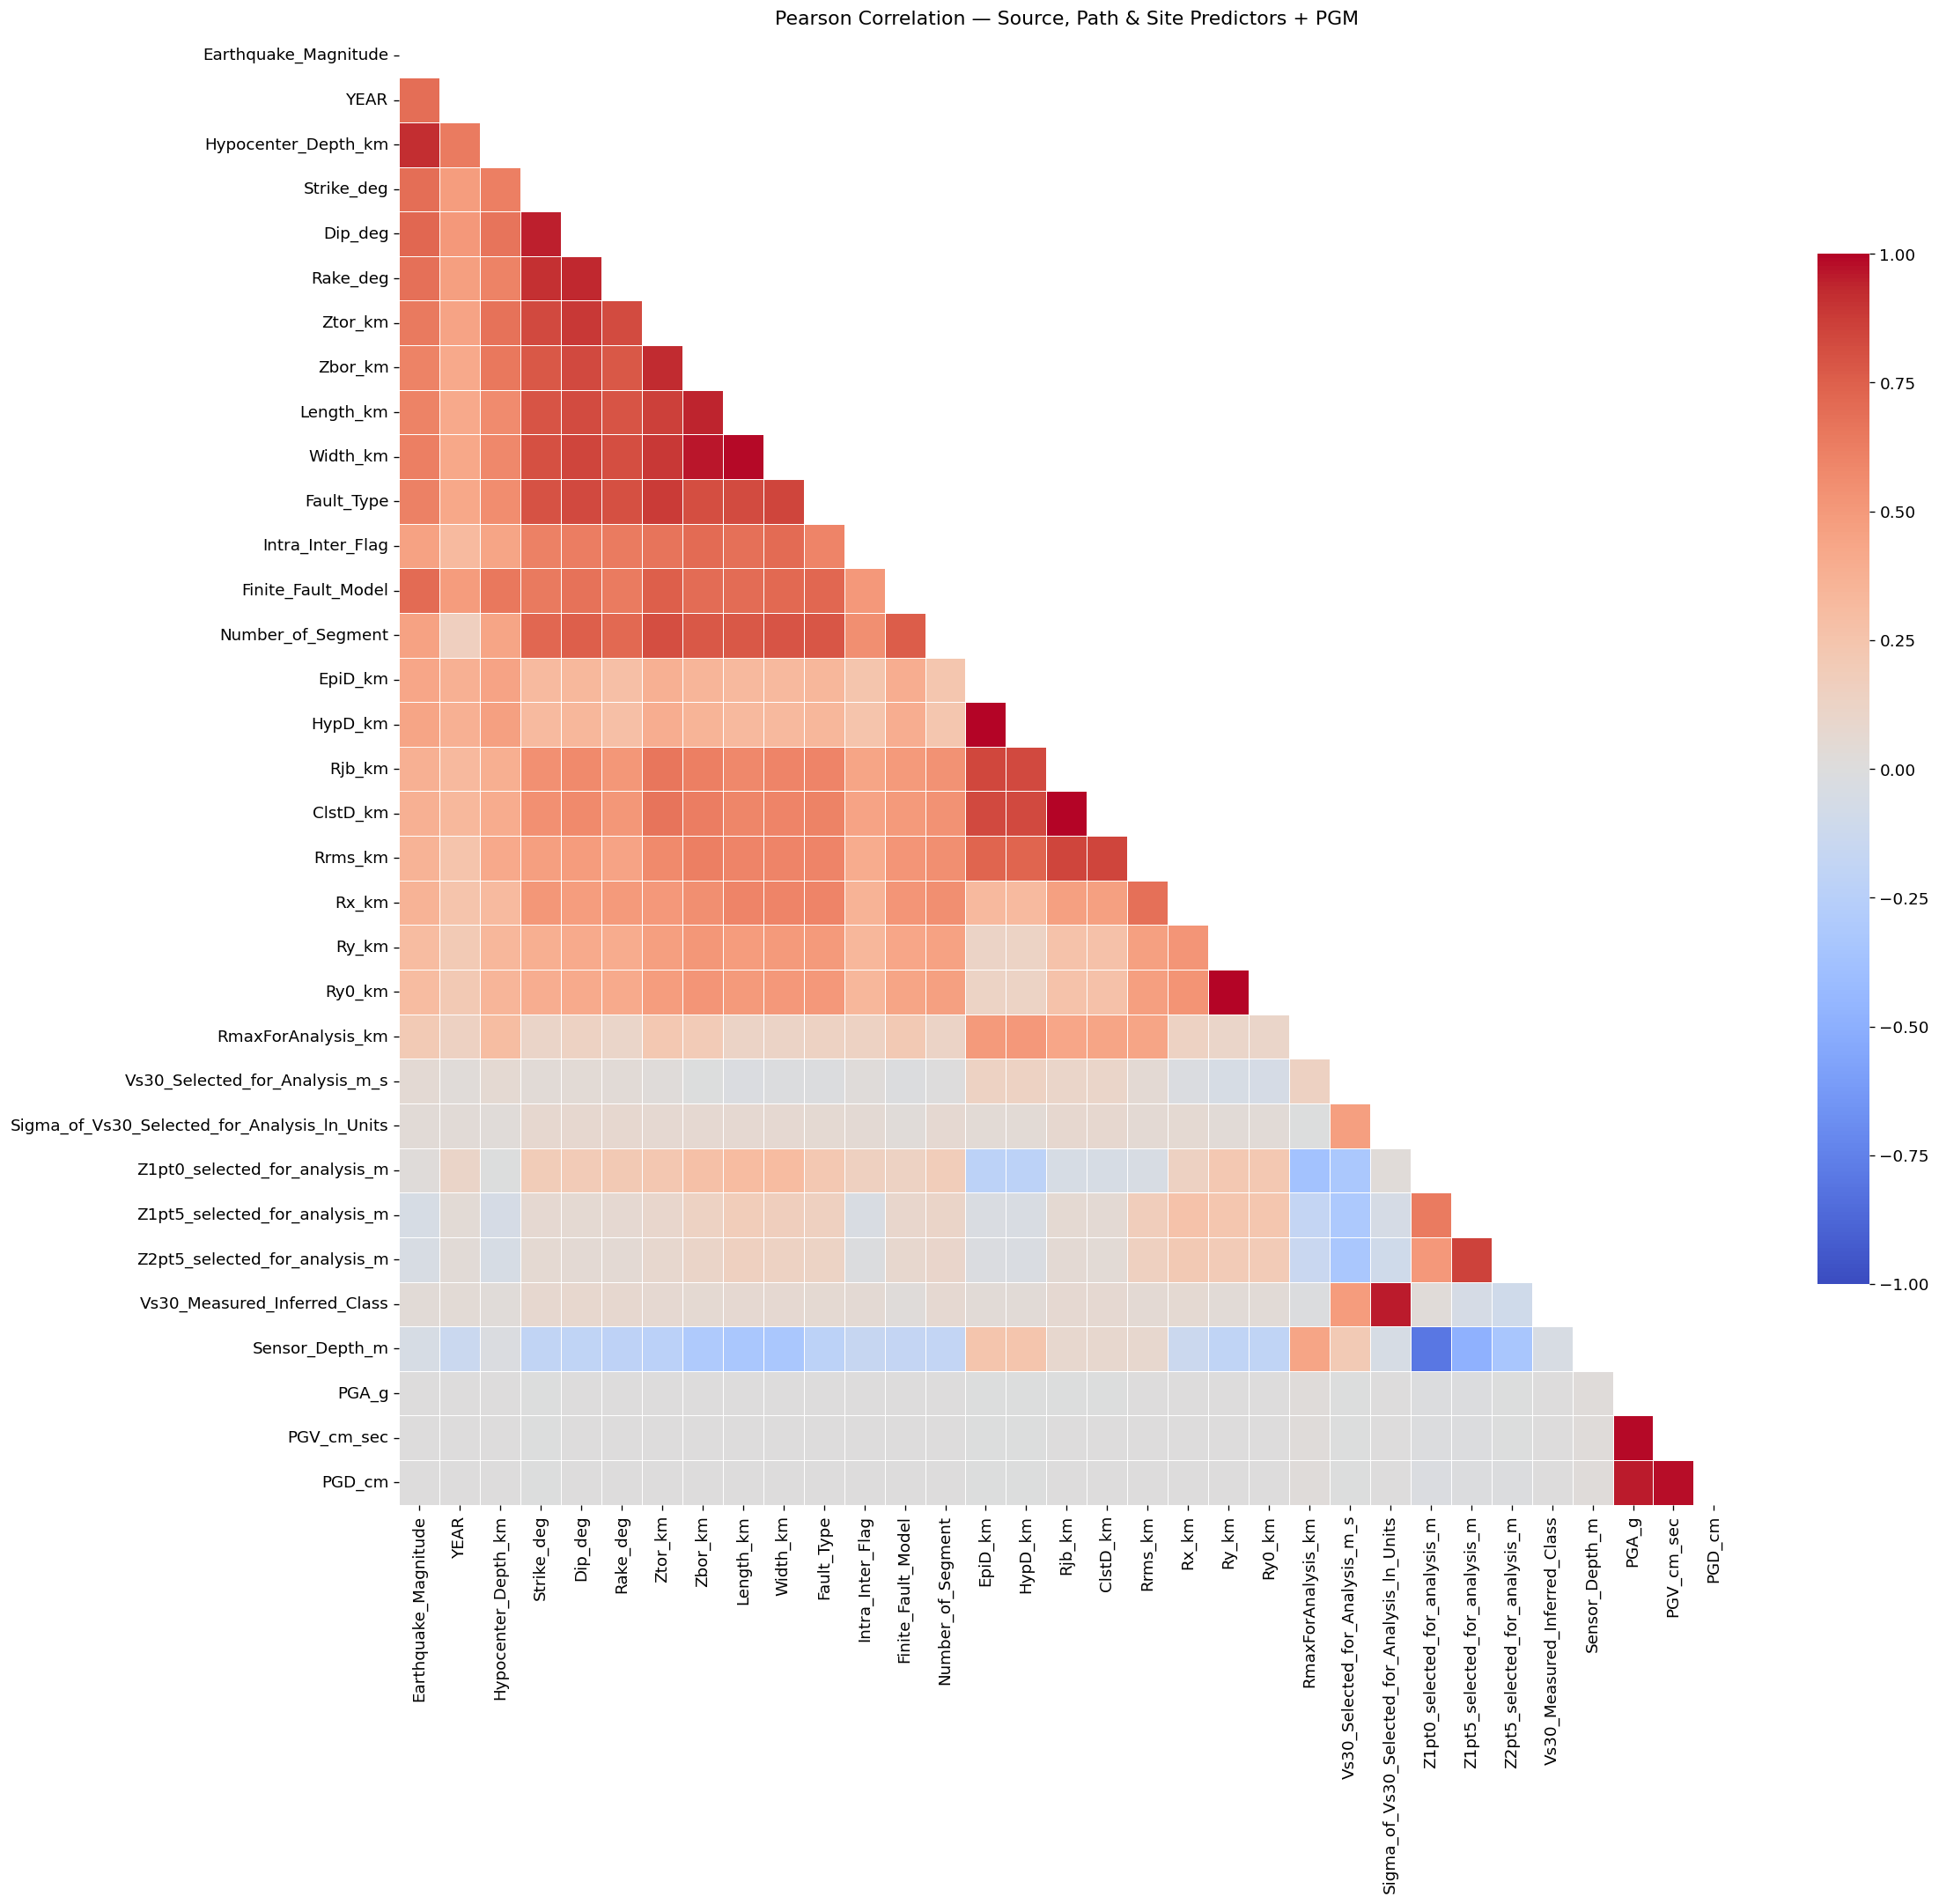

In [31]:
corr_cols = [c for c in source_cols + path_cols + site_cols + [c for c in pgm_cols if c in df.columns]
             if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]

corr_mat = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(max(10, len(corr_cols)*0.6), max(8, len(corr_cols)*0.55)))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=len(corr_cols) < 20, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('Pearson Correlation — Source, Path & Site Predictors + PGM')
plt.tight_layout()
plt.show()

In [32]:
# Highlight high correlations (|r| > 0.7)
high_corr = []
for i in range(len(corr_mat.columns)):
    for j in range(i+1, len(corr_mat.columns)):
        r = corr_mat.iloc[i, j]
        if abs(r) > 0.7:
            high_corr.append((corr_mat.columns[i], corr_mat.columns[j], round(r, 3)))

high_corr_df = pd.DataFrame(high_corr, columns=['Feature_A', 'Feature_B', 'r'])
print(f'Pairs with |r| > 0.7:')
print(high_corr_df.sort_values('r', key=abs, ascending=False).to_string(index=False))

Pairs with |r| > 0.7:
                                   Feature_A                     Feature_B      r
                                      Rjb_km                      ClstD_km  0.999
                                       Ry_km                        Ry0_km  0.998
                                     EpiD_km                       HypD_km  0.998
                                   Length_km                      Width_km  0.989
                                       PGA_g                    PGV_cm_sec  0.989
                                  PGV_cm_sec                        PGD_cm  0.978
                                     Zbor_km                      Width_km  0.966
Sigma_of_Vs30_Selected_for_Analysis_ln_Units  Vs30_Measured_Inferred_Class  0.957
                                       PGA_g                        PGD_cm  0.954
                                  Strike_deg                       Dip_deg  0.950
                                     Zbor_km                     Length_km  

---
## 16. Log-Normality Check of SA

**Why:** Standard GMM formulations assume log-normally distributed residuals. Verifying this assumption (Q-Q plots, normality tests) at a few key periods validates the log-linear modelling framework and highlights any heavy-tailed or skewed behavior.

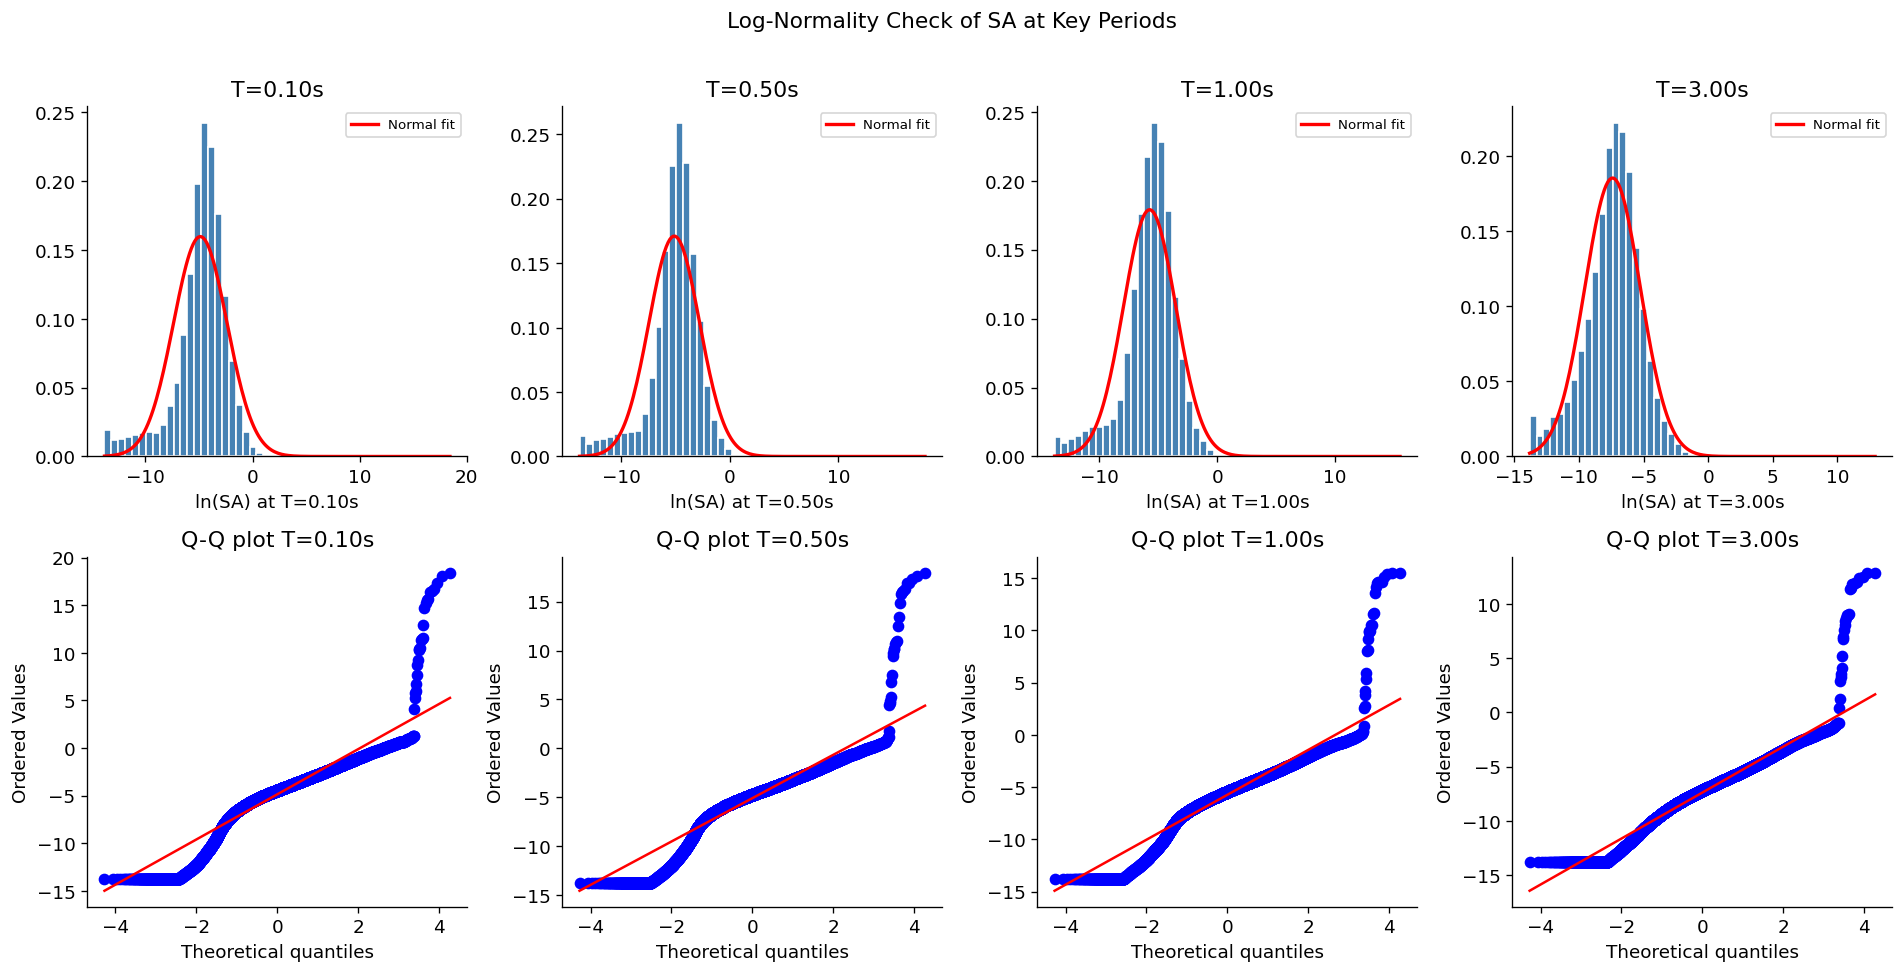

In [33]:
from scipy.stats import probplot, shapiro

check_T = [0.1, 0.5, 1.0, 3.0]

fig, axes = plt.subplots(2, len(check_T), figsize=(16, 8))

for i, T in enumerate(check_T):
    col, actual_T = nearest_col(T)
    vals = np.log(df[col].dropna().clip(lower=1e-6).values)

    # Histogram of log-SA
    axes[0, i].hist(vals, bins=50, color='steelblue', edgecolor='white', density=True)
    xrange = np.linspace(vals.min(), vals.max(), 200)
    axes[0, i].plot(xrange, stats.norm.pdf(xrange, vals.mean(), vals.std()),
                    'r-', linewidth=2, label='Normal fit')
    axes[0, i].set_xlabel(f'ln(SA) at T={actual_T:.2f}s')
    axes[0, i].set_title(f'T={actual_T:.2f}s')
    axes[0, i].legend(fontsize=8)

    # Q-Q plot
    probplot(vals, dist='norm', plot=axes[1, i])
    axes[1, i].set_title(f'Q-Q plot T={actual_T:.2f}s')

plt.suptitle('Log-Normality Check of SA at Key Periods', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

---
## 17. Temporal & Geographic Distribution

**Why:** Events clustered in time (aftershock sequences) or geography (single tectonic setting) can introduce biases. Temporal plots reveal catalogue completeness and geographic maps show which subduction zones dominate the dataset.

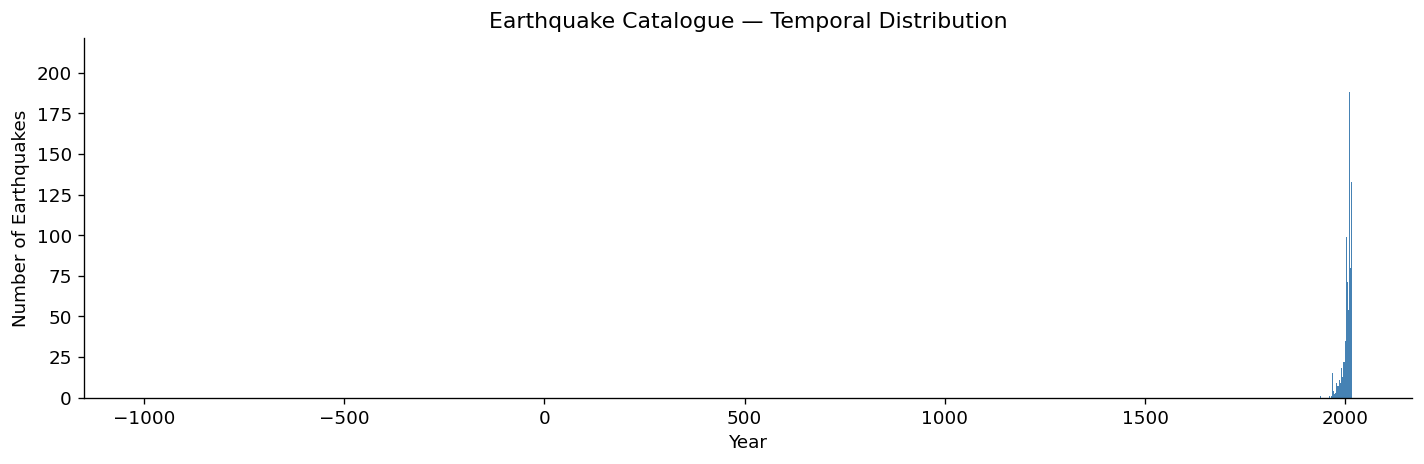

In [34]:
# Temporal distribution
if 'YEAR' in df.columns:
    year_counts = eq_df['YEAR'].value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(year_counts.index, year_counts.values, color='steelblue', width=0.8)
    ax.set_xlabel('Year')
    ax.set_ylabel('Number of Earthquakes')
    ax.set_title('Earthquake Catalogue — Temporal Distribution')
    plt.tight_layout()
    plt.show()

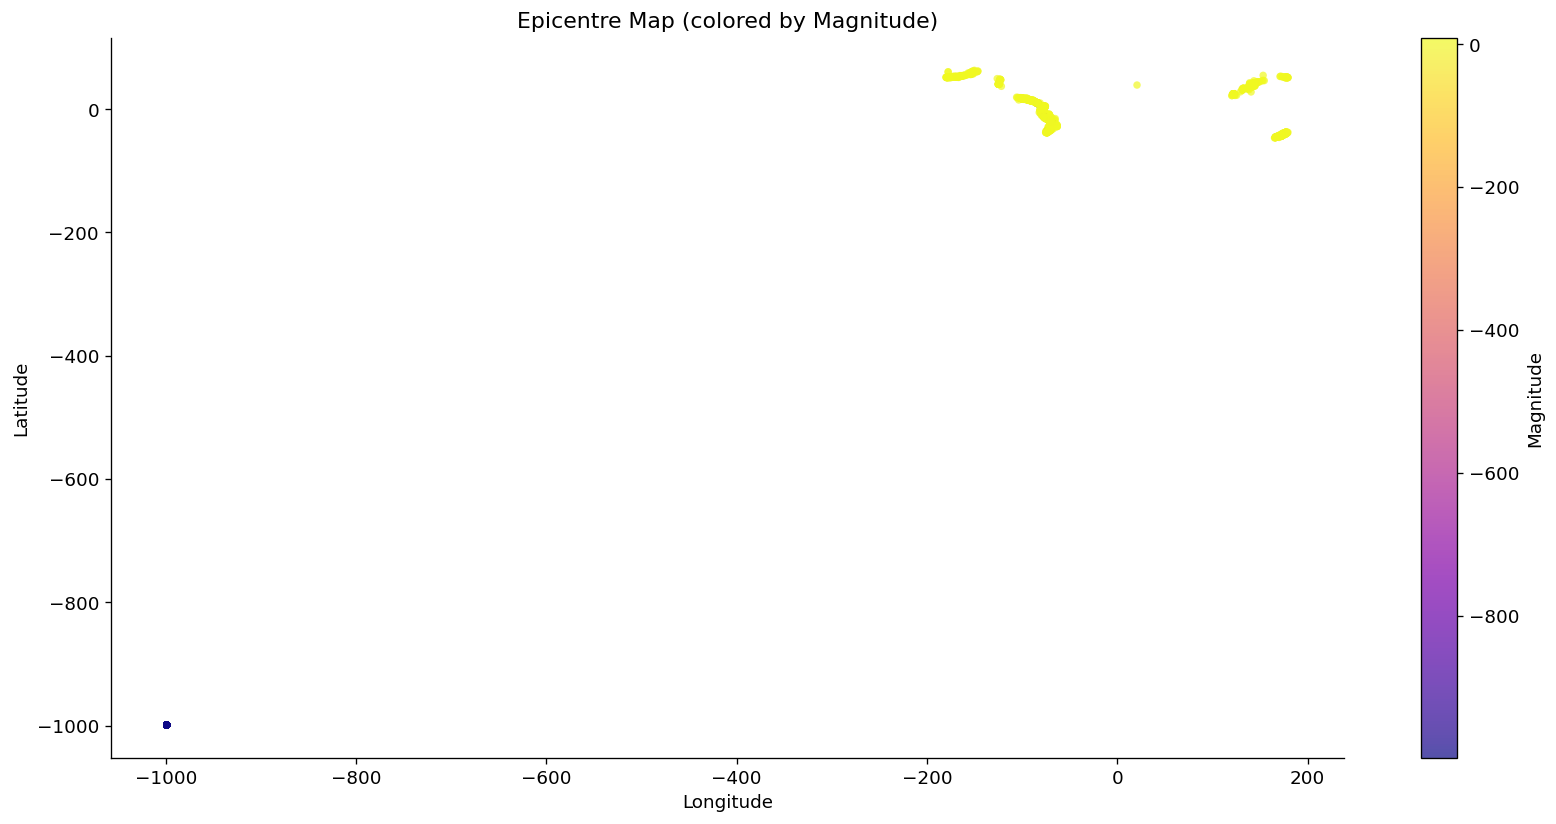

In [35]:
# Geographic scatter of epicentres
if all(c in df.columns for c in ['Hypocenter_Latitude_deg', 'Hypocenter_Longitude_deg']):
    eq_geo = eq_df.dropna(subset=['Hypocenter_Latitude_deg', 'Hypocenter_Longitude_deg'])

    fig, ax = plt.subplots(figsize=(14, 7))
    sc = ax.scatter(eq_geo['Hypocenter_Longitude_deg'],
                    eq_geo['Hypocenter_Latitude_deg'],
                    c=eq_geo['Earthquake_Magnitude'], cmap='plasma',
                    s=20, alpha=0.7, edgecolors='none')
    plt.colorbar(sc, ax=ax, label='Magnitude')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title('Epicentre Map (colored by Magnitude)')
    plt.tight_layout()
    plt.show()

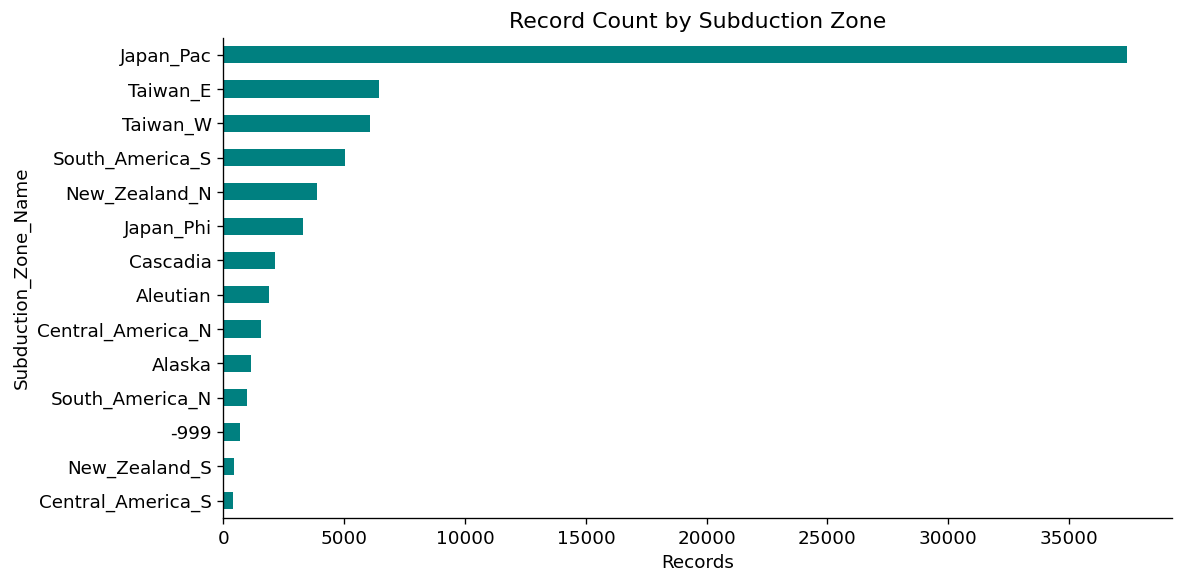

In [36]:
# Subduction zone breakdown
if 'Subduction_Zone_Name' in df.columns:
    vc = df['Subduction_Zone_Name'].value_counts(dropna=False).head(20)
    fig, ax = plt.subplots(figsize=(10, 5))
    vc.sort_values().plot.barh(ax=ax, color='teal')
    ax.set_title('Record Count by Subduction Zone')
    ax.set_xlabel('Records')
    plt.tight_layout()
    plt.show()

---
## 18. Sigma (Total Standard Deviation) Across Periods

**Why:** The total sigma (standard deviation of ln(SA)) across periods is a critical GMM output. Computing the raw data sigma (residuals from the median) across periods sets expectations for what any trained model must achieve.

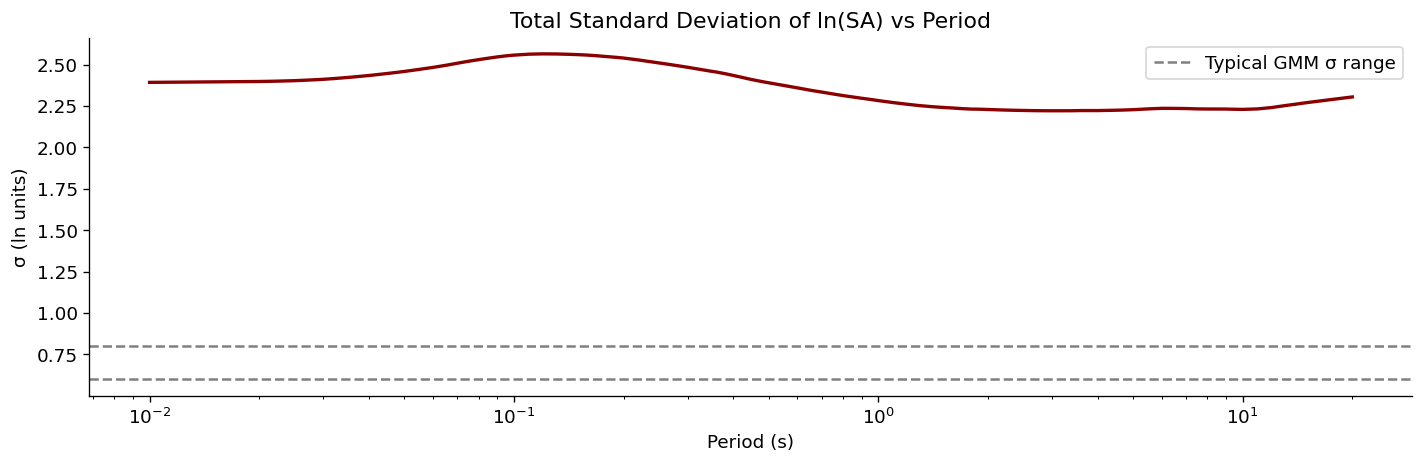

In [37]:
log_sa = np.log(sa_data.clip(lower=1e-9))
sigma_total = log_sa.std()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(T_vals, sigma_total.values, color='darkred', linewidth=2)
ax.set_xscale('log')
ax.set_xlabel('Period (s)')
ax.set_ylabel('σ (ln units)')
ax.set_title('Total Standard Deviation of ln(SA) vs Period')
ax.axhline(0.6, linestyle='--', color='gray', label='Typical GMM σ range')
ax.axhline(0.8, linestyle='--', color='gray')
ax.legend()
plt.tight_layout()
plt.show()

---
## 19. SA Cross-Period Correlation

**Why:** Cross-period correlations of ln(SA) are needed for vector-intensity-measure GMMs, hazard disaggregation, and conditional spectrum construction. Visualizing the correlation matrix reveals the expected decay with period separation.

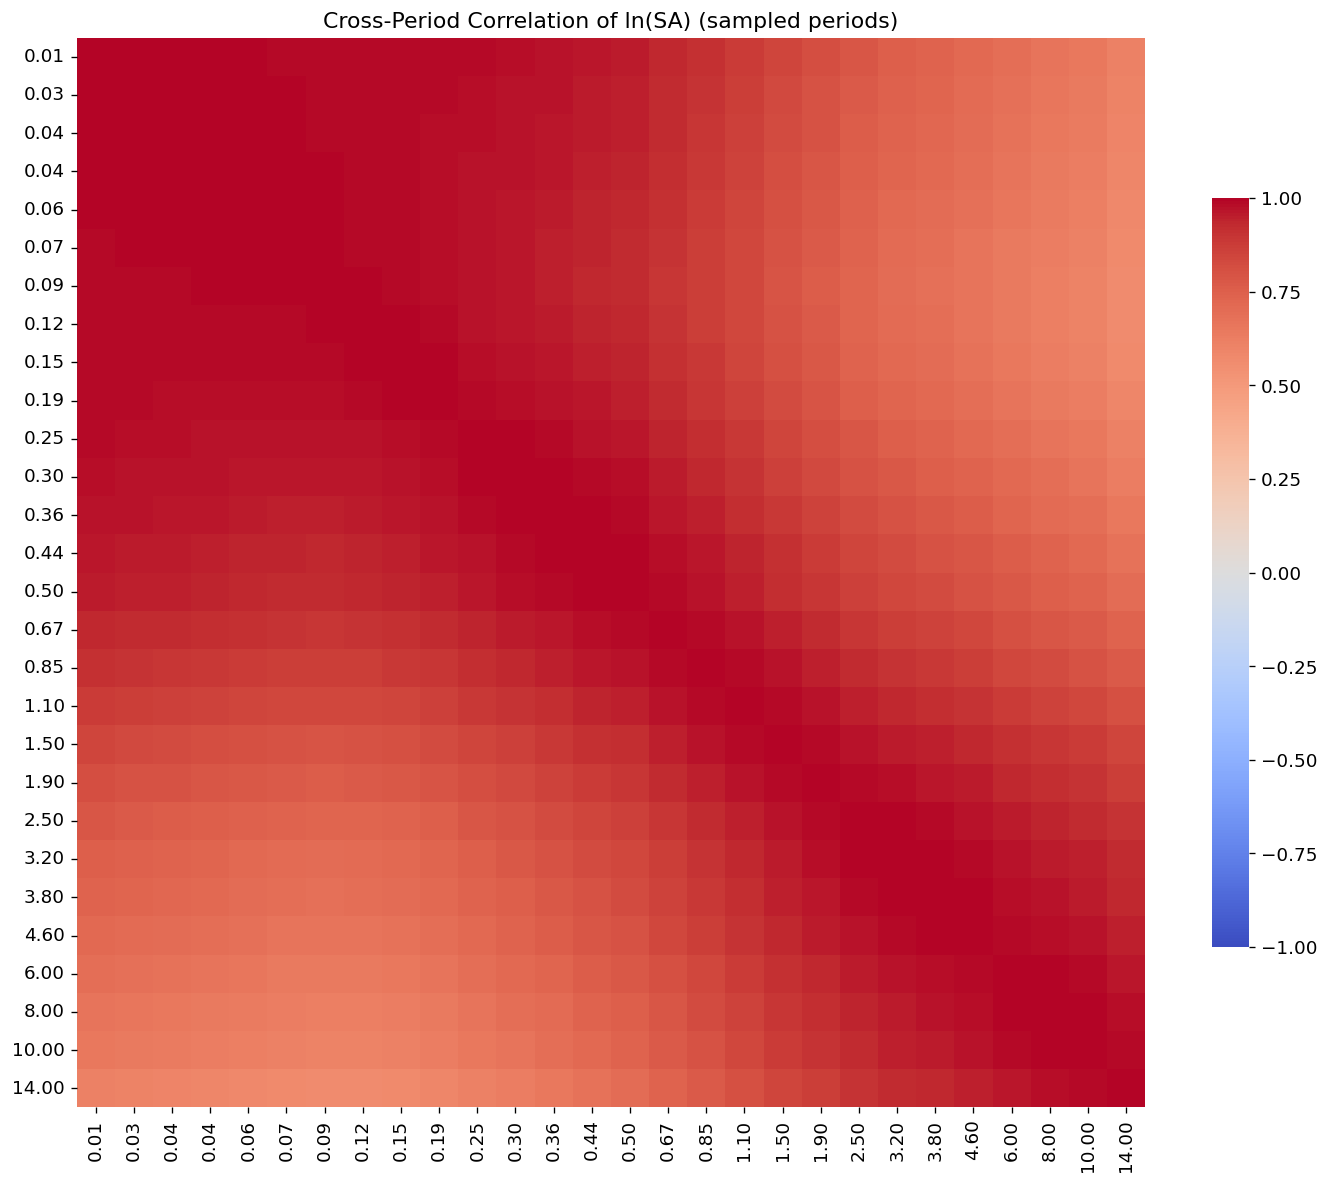

In [38]:
# Subsample periods to keep the heatmap readable
T_sample_idx = list(range(0, len(sa_col_sorted), max(1, len(sa_col_sorted)//25)))
sa_sample_cols = [sa_col_sorted[i] for i in T_sample_idx]
T_sample_vals  = [T_vals[i] for i in T_sample_idx]

log_sa_sample = np.log(df[sa_sample_cols].clip(lower=1e-9))
corr_sa = log_sa_sample.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_sa, xticklabels=[f'{t:.2f}' for t in T_sample_vals],
            yticklabels=[f'{t:.2f}' for t in T_sample_vals],
            cmap='coolwarm', vmin=-1, vmax=1, ax=ax,
            cbar_kws={'shrink': 0.7})
ax.set_title('Cross-Period Correlation of ln(SA) (sampled periods)')
plt.tight_layout()
plt.show()

---
## 20. Summary Statistics Table

**Why:** A final consolidated table of key predictors and response variables serves as a quick reference for the model training phase, capturing ranges, medians, and data counts after the EDA.

In [39]:
summary_cols = (['Earthquake_Magnitude', 'Hypocenter_Depth_km', 'Ztor_km',
                 'Dip_deg', 'Rake_deg'] +
                [c for c in path_cols if c in df.columns] +
                [c for c in site_cols if c in df.columns and pd.api.types.is_numeric_dtype(df[c])] +
                [c for c in pgm_cols if c in df.columns])

summary_cols = list(dict.fromkeys([c for c in summary_cols if c in df.columns]))

summary = df[summary_cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
summary.insert(0, 'Non-null', df[summary_cols].notnull().sum())
summary

,Non-null,count,mean,std,min,5%,25%,50%,75%,95%,max
Earthquake_Magnitude,71340,71340.0,-27.485617,1.809972e+02,-999.00,4.140000,5.560000,6.220000,6.820000,7.820000,9.120000e+00
Hypocenter_Depth_km,71340,71340.0,16.011815,2.056613e+02,-999.00,3.900000,18.471100,34.352100,52.000000,121.500000,6.275655e+02
Ztor_km,71340,71340.0,-27.970037,2.805525e+02,-999.00,-999.000000,8.650000,28.760000,46.726000,120.353400,6.170000e+02
Dip_deg,71340,71340.0,-23.262967,2.521408e+02,-999.00,-999.000000,20.000000,33.000000,59.000000,82.000000,9.000000e+01
Rake_deg,71340,71340.0,-25.719170,2.653028e+02,-999.00,-999.000000,-68.000000,74.000000,97.000000,149.000000,2.570000e+02
EpiD_km,71340,71340.0,293.386057,4.471370e+02,-999.00,21.227221,114.384230,219.387389,384.968652,1079.070614,1.929524e+04
HypD_km,71340,71340.0,304.535286,4.486080e+02,-999.00,43.885223,127.830612,225.151073,392.004785,1121.457420,1.929524e+04
Rjb_km,71340,71340.0,230.948128,4.883219e+02,-999.00,-999.000000,96.748162,196.691013,352.499527,1041.755030,6.508296e+03
ClstD_km,71340,71340.0,242.018657,4.909415e+02,-999.00,-999.000000,111.271116,203.729877,359.127174,1082.985162,6.508327e+03
Rrms_km,71340,71340.0,166.491745,5.949629e+02,-999.00,-999.000000,104.685308,210.535987,375.734387,1086.441683,6.519662e+03


---
## 21. EDA Findings — Pre-Training Checklist

Fill in findings from the analysis above before proceeding to GMM training.

In [40]:
checklist = {
    'Total records'                  : len(df),
    'Unique earthquakes'             : df['NGAsubEQID'].nunique(),
    'Unique stations'                : df['NGAsubSSN'].nunique() if 'NGAsubSSN' in df.columns else 'N/A',
    'Magnitude range'                : f"{df['Earthquake_Magnitude'].min():.1f} – {df['Earthquake_Magnitude'].max():.1f}",
    'Distance (ClstD) range (km)'    : f"{df.get('ClstD_km', df.get('Rjb_km')).min():.1f} – {df.get('ClstD_km', df.get('Rjb_km')).max():.1f}",
    'Vs30 range (m/s)'               : f"{df['Vs30_Selected_for_Analysis_m_s'].min():.0f} – {df['Vs30_Selected_for_Analysis_m_s'].max():.0f}" if 'Vs30_Selected_for_Analysis_m_s' in df.columns else 'N/A',
    'SA period range (s)'            : f"{min(T_vals):.3f} – {max(T_vals):.1f}",
    'Columns with >20% missing'      : list(miss_df[miss_df['Missing_%'] > 20].index[:10]),
    'Quality flags raised'           : {k: v for k, v in issues.items() if v > 0},
}

for k, v in checklist.items():
    print(f'{k:<40}: {v}')

Total records                           : 71340
Unique earthquakes                      : 1880
Unique stations                         : 6386
Magnitude range                         : -999.0 – 9.1
Distance (ClstD) range (km)             : -999.0 – 6508.3
Vs30 range (m/s)                        : -999 – 2230
SA period range (s)                     : 0.010 – 20.0
Columns with >20% missing               : []
Quality flags raised                    : {'EpiD_km ≤ 0': 2194, 'HypD_km ≤ 0': 2194, 'Rjb_km ≤ 0': 4909, 'ClstD_km ≤ 0': 4817, 'Rrms_km ≤ 0': 10297, 'Rx_km ≤ 0': 28884, 'Ry_km ≤ 0': 39942, 'Ry0_km ≤ 0': 41276, 'RmaxForAnalysis_km ≤ 0': 4835, 'Vs30 < 50 m/s': 539, 'PGA > 3 g': 26, 'Magnitude < 4': 2867, 'Depth < 0 km': 2473}
